In [731]:
# !pip install seaborn


In [732]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import scipy.stats as stats
import itertools
from matplotlib.ticker import FixedLocator, FixedFormatter, LogLocator, NullFormatter




In [733]:
# SPW version helper functions
# Existing RSVP/reading values are log10(WPM). Convert plotting copies to log10(sec/word).
def log_wpm_to_log_spw(log_wpm):
    return np.log10(60) - log_wpm


def with_log_spw(df, col):
    df_spw = df.copy()
    df_spw[col] = log_wpm_to_log_spw(df_spw[col])
    return df_spw


def log_ratio_wpm_to_spw(log_ratio):
    return -log_ratio


# Import data
- all thresholds: df_both_sessions

In [734]:
df_both_sessions = pd.read_csv('tidy_both_sessions_thresholds_log.csv')

In [735]:
num_thresholds_per_subj = 18
assert df_both_sessions["prolificID"].nunique() == len(df_both_sessions) / num_thresholds_per_subj, 'Fatal: Number of thresholds per subject does not match'

print(f'\nNumber of participants with both sessions: {df_both_sessions["prolificID"].nunique()}')


Number of participants with both sessions: 169


In [736]:
# # Update meridian values for reading tasks
# df_both_sessions.loc[
#     (df_both_sessions['taskName'] == 'reading') & 
#     (df_both_sessions['meridian'].isin(['Beaver', 'Desert'])),
#     'meridian'
# ] = 'first'

# df_both_sessions.loc[
#     (df_both_sessions['taskName'] == 'reading') & 
#     (df_both_sessions['meridian'].isin(['Winter', 'Islands'])),
#     'meridian'
# ] = 'second'

# Data cleaning

## Filter participants based on the quality of individual thresholds
Exclude participants with:
- acuity and crowding: numTrialsSent < 35, questSD > 0.1
- rsvp: numTrialsSent < 24, questSD > 0.1
- ordinary reading: accuracy < 60

Outputs: prolificID of participants excluded based on each criteria. 
- {taskName}_low_trial_ids
- {taskName}_large_questSD_ids
- reading_low_accuracy_ids

In [737]:
# num_trials_required = 23  # 23 trials for short staircase
num_trials_required = 35  # 35 trials for original staircase

acuity_low_trial_ids = (
    df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["acuity"]) & (df_both_sessions["numTrialsSent"] < num_trials_required),
        "prolificID"
    ]
    .unique()
)
print(f'Number of participants with at least 1 threshold with number of trials < {num_trials_required}: {len(acuity_low_trial_ids)}')

acuity_large_questSD_ids = (
	df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["acuity"]) & (df_both_sessions["questSD"] > 0.1),
        "prolificID"
	]
    .unique()
)
print(f'Number of participants with at least 1 threshold with questSD > 0.1: {len(acuity_large_questSD_ids)}')


Number of participants with at least 1 threshold with number of trials < 35: 16
Number of participants with at least 1 threshold with questSD > 0.1: 3


In [738]:
# num_trials_required = 23  # 23 trials for short staircase
num_trials_required = 35  # 35 trials for original staircase

crowding_low_trial_ids = (
    df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["crowding"]) & (df_both_sessions["numTrialsSent"] < num_trials_required),
        "prolificID"
    ]
    .unique()
)
print(f'Number of participants with at least 1 threshold with number of trials < {num_trials_required}: {len(crowding_low_trial_ids)}')

crowding_large_questSD_ids = (
    df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["crowding"]) & (df_both_sessions["questSD"] > 0.1),
        "prolificID"
    ]
    .unique()
)
print(f'Number of participants with at least 1 threshold with questSD > 0.1: {len(crowding_large_questSD_ids)}')


Number of participants with at least 1 threshold with number of trials < 35: 22
Number of participants with at least 1 threshold with questSD > 0.1: 28


In [739]:
# num_trials_required = 16  # 16 trials for short staircase
num_trials_required = 24  # 24 trials for original staircase

rsvp_low_trial_ids = (
    df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["rsvp"]) & (df_both_sessions["numTrialsSent"] < num_trials_required),
        "prolificID"
    ]
    .unique()
)
print(f'Number of participants with at least 1 threshold with number of trials < {num_trials_required}: {len(rsvp_low_trial_ids)}')

rsvp_large_questSD_ids = (
    df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["rsvp"]) & (df_both_sessions["questSD"] > 0.1),
        "prolificID"
    ]
    .unique()
)
print(f'Number of participants with at least 1 threshold with questSD > 0.1: {len(rsvp_large_questSD_ids)}')


Number of participants with at least 1 threshold with number of trials < 24: 0
Number of participants with at least 1 threshold with questSD > 0.1: 11


In [740]:
reading_low_accuracy_ids = (
    df_both_sessions.loc[
        df_both_sessions["taskName"].isin(["reading"]) & (df_both_sessions["readingCQAccuracy"] < 60),
        "prolificID"
    ]
    .unique()
)
print(f'Number of participants with at least 1 measurement with accuracy < 60%: {len(reading_low_accuracy_ids)}')


Number of participants with at least 1 measurement with accuracy < 60%: 63


## Compute the geometric mean of thresholds
- within the same block (one threshold per block): df_gmean_block
- across blocks for each task (one threshold per task): df_gmean_task
- within the same meridian (one threshold per meridian): df_gmean_meridian
- all data are logged so we can simply take the mean

In [741]:
# Group by participant, task, and repeat
df_gmean_block = (
    df_both_sessions.groupby(["prolificID", "taskName", "repeat"], observed=True)
					.agg(gmean_threshold_block=("threshold", lambda x: np.mean(x.dropna())))
					.reset_index()
)
df_gmean_block

,prolificID,taskName,repeat,gmean_threshold_block
0,559ad287fdf99b219a612d22,acuity,1,-0.415187
1,559ad287fdf99b219a612d22,acuity,2,-0.480609
2,559ad287fdf99b219a612d22,crowding,1,0.845687
3,559ad287fdf99b219a612d22,crowding,2,0.882659
4,559ad287fdf99b219a612d22,crowding,3,0.950354
...,...,...,...,...
1685,67fffee26ec983c07f3a2abd,crowding,4,0.140155
1686,67fffee26ec983c07f3a2abd,reading,1,2.102490
1687,67fffee26ec983c07f3a2abd,reading,2,2.279796
1688,67fffee26ec983c07f3a2abd,rsvp,1,2.543958


In [742]:
# Group by participant, task, and repeat
df_gmean_task = (
    df_both_sessions.groupby(["prolificID", "taskName"], observed=True)
					.agg(gmean_threshold_task=("threshold", lambda x: np.mean(x.dropna())))
					.reset_index()
)
df_gmean_task

,prolificID,taskName,gmean_threshold_task
0,559ad287fdf99b219a612d22,acuity,-0.447898
1,559ad287fdf99b219a612d22,crowding,0.929865
2,559ad287fdf99b219a612d22,reading,2.278744
3,559ad287fdf99b219a612d22,rsvp,2.633234
4,55d51a6b8ce09000127d4821,acuity,-0.633734
...,...,...,...
671,67e461f383bb0fc948ffd5fd,rsvp,3.175839
672,67fffee26ec983c07f3a2abd,acuity,-0.476663
673,67fffee26ec983c07f3a2abd,crowding,0.352948
674,67fffee26ec983c07f3a2abd,reading,2.191143


In [743]:
# Group by participant, task, and repeat
df_gmean_meridian = (
    df_both_sessions.groupby(["prolificID", "taskName","meridian"], observed=True)
					.agg(gmean_threshold_meridian=("threshold", lambda x: np.mean(x.dropna())))
					.reset_index()
)
df_gmean_meridian

,prolificID,taskName,meridian,gmean_threshold_meridian
0,559ad287fdf99b219a612d22,acuity,L8,-0.415579
1,559ad287fdf99b219a612d22,acuity,R8,-0.480217
2,559ad287fdf99b219a612d22,crowding,L8,1.094984
3,559ad287fdf99b219a612d22,crowding,R8,0.764746
4,559ad287fdf99b219a612d22,reading,first,2.311957
...,...,...,...,...
1178,67fffee26ec983c07f3a2abd,crowding,L8,0.504142
1179,67fffee26ec983c07f3a2abd,crowding,R8,0.201753
1180,67fffee26ec983c07f3a2abd,reading,first,2.276611
1181,67fffee26ec983c07f3a2abd,reading,second,2.105675


## Filter participants based on test-retest ratio
- log(test/retest), i.e., log(test) - log(retest), note: not the ratio of the logged thresholds; take the ratio between the numerical thresholds and then take the log.
- if test and retest are very different, then it means that the participant is unreliable and therefore should be excluded 

Outputs: prolificID of participants with large test-retest ratio
- {taskName}_bad_ratio_ids

### Functions:

In [744]:
def compute_test_retest_ratio(df, block1_colname, block2_colname):
	'''
	Compute test-retest ratio: log10(block2 / block1)
    Since the data are already log-transformed, the results would be equivalent to:
    block2 - block1
	'''
	return df[block2_colname] - df[block1_colname]

def flag_outliers_IQR(
    df,
    col_prefix="log_ratio_",
    criterion_k=1.5,
    verbose=True,
):
    """
    Add boolean outlier flags to ratio columns in a pivot table.

    - Detects columns via `col_prefix`.
    - For each ratio col: computes Q1, Q3, IQR; flags values < Q1 - k*IQR or > Q3 + k*IQR.
    - Writes a boolean flag column '<ratio_col>_is_outlier'.
    Returns a new DataFrame (does not modify input).
    """
    df = df.copy()

    # Identify ratio columns
    colNames = [c for c in df.columns if c.startswith(col_prefix)]

    for col in colNames:
        # Compute IQR bounds (NaNs ignored by quantile)
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - criterion_k * iqr
        upper = q3 + criterion_k * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        out_col = f"{col}_is_outlier"
        df[out_col] = mask.fillna(False)

        if verbose:
            n = int(mask.sum())
            print(f"{col}: Q1={q1:.4f}, Q3={q3:.4f}, IQR={iqr:.4f}, "
                  f"bounds=({lower:.4f}, {upper:.4f}), outliers={n}")

    return df


def exclusion_ids_from_flags(
    df_wide: pd.DataFrame,
    task: str,
    flag_cols=None,                 # e.g., ["log_ratio_2vs1_is_outlier"] or None → auto-pick all *_is_outlier
    require="any",                  # "any" = exclude if ANY flag True; "all" = exclude only if ALL flags True
):
    """
    Return a list of prolificID to exclude for a given task, based on boolean outlier flags.
    df_wide must include columns: 'prolificID', 'taskName', and *_is_outlier booleans.
    """
    d = df_wide[df_wide["taskName"] == task]

    if flag_cols is None:
        flag_cols = [c for c in d.columns if c.endswith("_is_outlier")]

    if not flag_cols:
        return []  # nothing to check

    if require == "any":
        bad = d.groupby("prolificID")[flag_cols].any().any(axis=1)
    elif require == "all":
        bad = d.groupby("prolificID")[flag_cols].all().all(axis=1)
    else:
        raise ValueError("Invalid require value. Use 'any' or 'all'.")
    return bad[bad].index.tolist()

def filter_excluding_ids(df_wide: pd.DataFrame, *exclude_lists):
    """
    Return df_wide with rows whose prolificID is NOT in any of the exclude lists.
    Accepts multiple lists/sets of IDs.
    """
    # Merge all input lists/sets into one set
    exclude_ids = set().union(*exclude_lists)
    return df_wide[~df_wide["prolificID"].isin(exclude_ids)].copy()

def filter_including_ids(df_wide: pd.DataFrame, *include_lists):
    """
    Return df_wide with rows whose prolificID IS IN any of the exclude lists.
    Accepts multiple lists/sets of IDs.
    """
    # Merge all input lists/sets into one set
    include_ids = set().union(*include_lists)
    return df_wide[df_wide["prolificID"].isin(include_ids)].copy()


In [745]:
def plot_ratio(data_array, title, num_bins=80, min_val=-2.5, max_val=2.5, abs_bool=False): # , num_bins=20, min_val=0.08, max_val=1.11
    '''
    Input:
    - data_array: an array of test-retest ratios
    - title: [string] title and x-axis label of the figure
    '''
    
    # make the bins look the same size on a log scale
    # min_val = round(np.nanmin(data_array),2)
    # max_val = round(np.nanmax(data_array),2)
    # print(f'Min and max bin limits: {min_val}, {max_val}')
    bins = np.linspace(min_val, max_val, num_bins + 1)
    if abs_bool:
        data_array = np.abs(data_array)
        title = 'Absolute ' + title
                
    plt.figure(figsize=(8, 2)) 
    plt.hist(data_array, bins=bins, color='lightyellow', edgecolor='black')# bins=bins
    plt.title(f"{title} (n = {np.count_nonzero(~np.isnan(data_array))})", fontsize = 16)
    plt.xlabel(title, fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.xlim(min_val, max_val)
    # plt.ylim(0,100)
    # add ticks and format them as normal floats
    # tick_positions = np.linspace(0.1, 1, num=10)  
    # plt.xticks(tick_positions, labels=[f"{x:.1f}" for x in tick_positions])

    
    plt.show()

### Compute ratios:

In [746]:
df_gmean_block_wide = (df_gmean_block
        .pivot(index=["prolificID", "taskName"],
               columns="repeat",
               values="gmean_threshold_block")
        .rename(columns={1: "block1", 2: "block2", 3: "block3", 4: "block4"})
        .reset_index())

df_gmean_block_wide

repeat,prolificID,taskName,block1,block2,block3,block4
0,559ad287fdf99b219a612d22,acuity,-0.415187,-0.480609,NaN,NaN
1,559ad287fdf99b219a612d22,crowding,0.845687,0.882659,0.950354,1.040760
2,559ad287fdf99b219a612d22,reading,2.322498,2.234990,NaN,NaN
3,559ad287fdf99b219a612d22,rsvp,2.523579,2.742889,NaN,NaN
4,55d51a6b8ce09000127d4821,acuity,-0.596659,-0.670809,NaN,NaN
...,...,...,...,...,...,...
671,67e461f383bb0fc948ffd5fd,rsvp,3.190082,3.161596,NaN,NaN
672,67fffee26ec983c07f3a2abd,acuity,-0.398057,-0.555268,NaN,NaN
673,67fffee26ec983c07f3a2abd,crowding,0.532112,0.631514,0.108010,0.140155
674,67fffee26ec983c07f3a2abd,reading,2.102490,2.279796,NaN,NaN


In [747]:
df_gmean_block_wide['log_ratio_2vs1'] = compute_test_retest_ratio(df_gmean_block_wide, 'block1', 'block2')
df_gmean_block_wide['log_ratio_3vs1'] = compute_test_retest_ratio(df_gmean_block_wide, 'block1', 'block3')
df_gmean_block_wide['log_ratio_4vs1'] = compute_test_retest_ratio(df_gmean_block_wide, 'block1', 'block4')
df_gmean_block_wide['log_ratio_3vs2'] = compute_test_retest_ratio(df_gmean_block_wide, 'block2', 'block3')
df_gmean_block_wide['log_ratio_4vs2'] = compute_test_retest_ratio(df_gmean_block_wide, 'block2', 'block4')
df_gmean_block_wide['log_ratio_4vs3'] = compute_test_retest_ratio(df_gmean_block_wide, 'block3', 'block4')

In [748]:
display(df_gmean_block_wide)

repeat,prolificID,taskName,block1,block2,block3,block4,log_ratio_2vs1,log_ratio_3vs1,log_ratio_4vs1,log_ratio_3vs2,log_ratio_4vs2,log_ratio_4vs3
0,559ad287fdf99b219a612d22,acuity,-0.415187,-0.480609,NaN,NaN,-0.065422,NaN,NaN,NaN,NaN,NaN
1,559ad287fdf99b219a612d22,crowding,0.845687,0.882659,0.950354,1.040760,0.036972,0.104667,0.195073,0.067695,0.158101,0.090406
2,559ad287fdf99b219a612d22,reading,2.322498,2.234990,NaN,NaN,-0.087507,NaN,NaN,NaN,NaN,NaN
3,559ad287fdf99b219a612d22,rsvp,2.523579,2.742889,NaN,NaN,0.219310,NaN,NaN,NaN,NaN,NaN
4,55d51a6b8ce09000127d4821,acuity,-0.596659,-0.670809,NaN,NaN,-0.074150,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
671,67e461f383bb0fc948ffd5fd,rsvp,3.190082,3.161596,NaN,NaN,-0.028486,NaN,NaN,NaN,NaN,NaN
672,67fffee26ec983c07f3a2abd,acuity,-0.398057,-0.555268,NaN,NaN,-0.157210,NaN,NaN,NaN,NaN,NaN
673,67fffee26ec983c07f3a2abd,crowding,0.532112,0.631514,0.108010,0.140155,0.099403,-0.424102,-0.391956,-0.523505,-0.491359,0.032145
674,67fffee26ec983c07f3a2abd,reading,2.102490,2.279796,NaN,NaN,0.177307,NaN,NaN,NaN,NaN,NaN


### Plot ratios before filtering

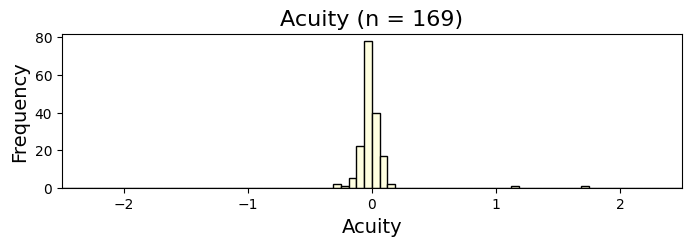

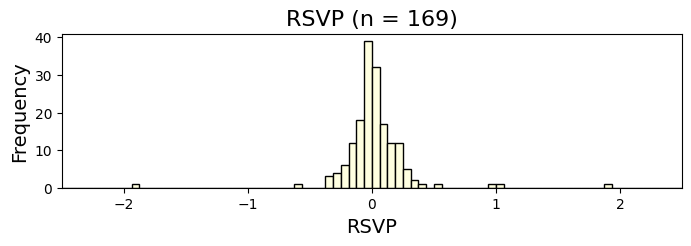

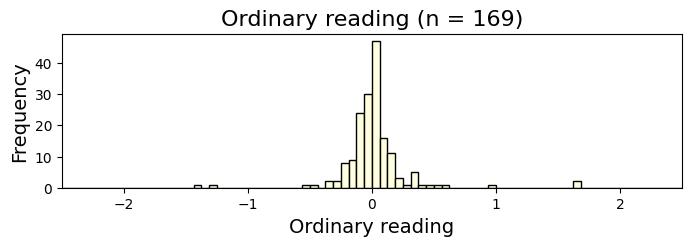

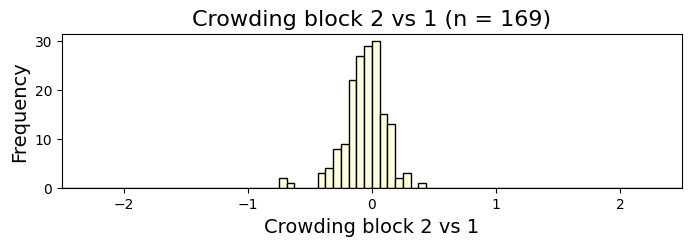

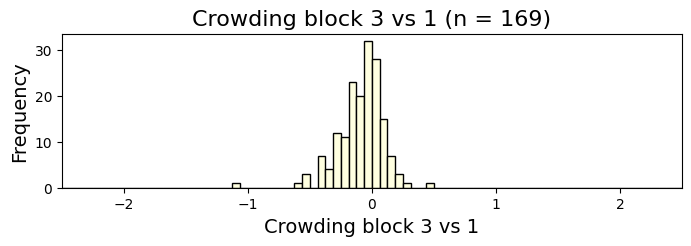

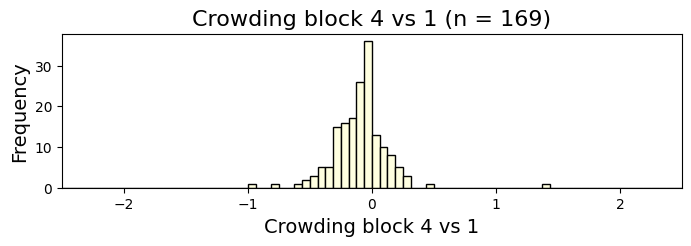

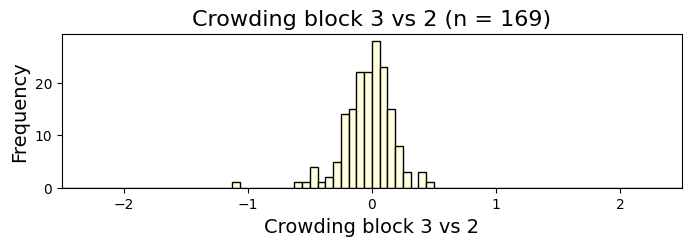

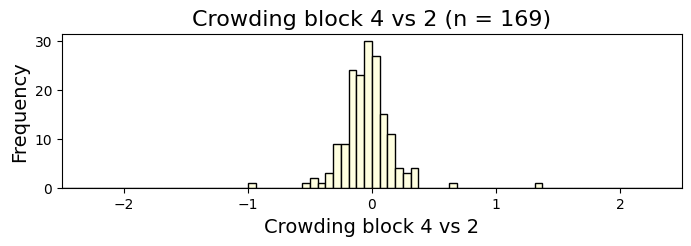

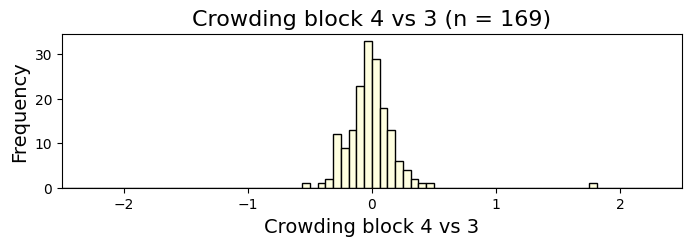

In [749]:
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "acuity"]['log_ratio_2vs1'], 'Acuity')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "rsvp"]['log_ratio_2vs1'], 'RSVP')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "reading"]['log_ratio_2vs1'], 'Ordinary reading')

plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "crowding"]['log_ratio_2vs1'], 'Crowding block 2 vs 1')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "crowding"]['log_ratio_3vs1'], 'Crowding block 3 vs 1')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "crowding"]['log_ratio_4vs1'], 'Crowding block 4 vs 1')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "crowding"]['log_ratio_3vs2'], 'Crowding block 3 vs 2')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "crowding"]['log_ratio_4vs2'], 'Crowding block 4 vs 2')
plot_ratio(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "crowding"]['log_ratio_4vs3'], 'Crowding block 4 vs 3')


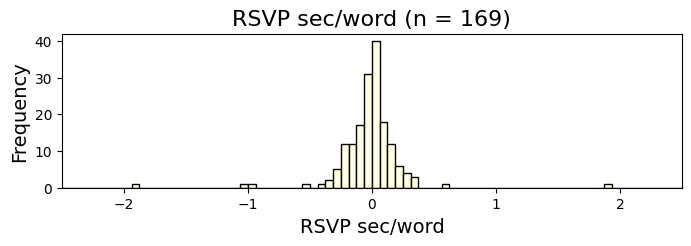

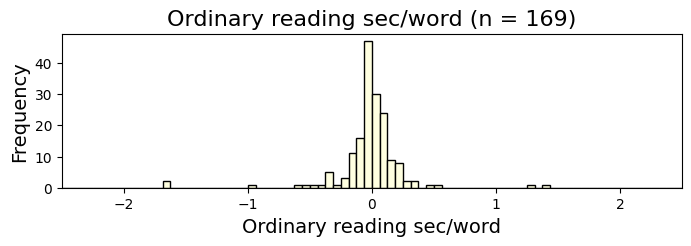

In [750]:
# SPW version: test-retest ratios for speed tasks
plot_ratio(log_ratio_wpm_to_spw(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "rsvp"]['log_ratio_2vs1']), 'RSVP sec/word')
plot_ratio(log_ratio_wpm_to_spw(df_gmean_block_wide[df_gmean_block_wide["taskName"] == "reading"]['log_ratio_2vs1']), 'Ordinary reading sec/word')


### Flag outliers

In [751]:
df_gmean_block_wide_flaggedOutliers = df_gmean_block_wide.copy()
df_gmean_block_wide_flaggedOutliers = flag_outliers_IQR(df_gmean_block_wide_flaggedOutliers)

log_ratio_2vs1: Q1=-0.0792, Q3=0.0543, IQR=0.1335, bounds=(-0.2794, 0.2545), outliers=59
log_ratio_3vs1: Q1=-0.1719, Q3=0.0235, IQR=0.1954, bounds=(-0.4650, 0.3166), outliers=6
log_ratio_4vs1: Q1=-0.2062, Q3=-0.0020, IQR=0.2042, bounds=(-0.5126, 0.3043), outliers=6
log_ratio_3vs2: Q1=-0.1309, Q3=0.0897, IQR=0.2206, bounds=(-0.4618, 0.4206), outliers=7
log_ratio_4vs2: Q1=-0.1476, Q3=0.0505, IQR=0.1981, bounds=(-0.4447, 0.3477), outliers=6
log_ratio_4vs3: Q1=-0.1099, Q3=0.0722, IQR=0.1822, bounds=(-0.3832, 0.3454), outliers=5


In [752]:
display(df_gmean_block_wide_flaggedOutliers.head())

repeat,prolificID,taskName,block1,block2,block3,block4,log_ratio_2vs1,log_ratio_3vs1,log_ratio_4vs1,log_ratio_3vs2,log_ratio_4vs2,log_ratio_4vs3,log_ratio_2vs1_is_outlier,log_ratio_3vs1_is_outlier,log_ratio_4vs1_is_outlier,log_ratio_3vs2_is_outlier,log_ratio_4vs2_is_outlier,log_ratio_4vs3_is_outlier
0,559ad287fdf99b219a612d22,acuity,-0.415187,-0.480609,NaN,NaN,-0.065422,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
1,559ad287fdf99b219a612d22,crowding,0.845687,0.882659,0.950354,1.04076,0.036972,0.104667,0.195073,0.067695,0.158101,0.090406,False,False,False,False,False,False
2,559ad287fdf99b219a612d22,reading,2.322498,2.234990,NaN,NaN,-0.087507,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
3,559ad287fdf99b219a612d22,rsvp,2.523579,2.742889,NaN,NaN,0.219310,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
4,55d51a6b8ce09000127d4821,acuity,-0.596659,-0.670809,NaN,NaN,-0.074150,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False


### List participants filtered out by test-retest ratios

In [753]:
# exclude all participants with any outlier in any of the crowding ratios
acuity_bad_ratio_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='acuity', flag_cols=["log_ratio_2vs1_is_outlier"])
crowding_bad_ratio_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding')
rsvp_bad_ratio_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='rsvp', flag_cols=["log_ratio_2vs1_is_outlier"])
reading_bad_ratio_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='reading', flag_cols=["log_ratio_2vs1_is_outlier"])

df_all_acuity = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "acuity"]
df_filtered_acuity = filter_excluding_ids(df_all_acuity, acuity_bad_ratio_ids)

df_all_rsvp = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "rsvp"]
df_filtered_rsvp = filter_excluding_ids(df_all_rsvp, rsvp_bad_ratio_ids)

df_all_reading = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "reading"]
df_filtered_reading = filter_excluding_ids(df_all_reading, reading_bad_ratio_ids)

# Below are exclusiong ids for individual crowding ratios. Created for plotting ratios after exclusion.
crowding_exclude_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding', flag_cols=["log_ratio_2vs1_is_outlier"])
df_all_crowding = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "crowding"]
df_filtered_crowding21 = filter_excluding_ids(df_all_crowding, crowding_exclude_ids)

crowding_exclude_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding', flag_cols=["log_ratio_3vs1_is_outlier"])
df_all_crowding = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "crowding"]
df_filtered_crowding31 = filter_excluding_ids(df_all_crowding, crowding_exclude_ids)

crowding_exclude_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding', flag_cols=["log_ratio_4vs1_is_outlier"])
df_all_crowding = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "crowding"]
df_filtered_crowding41 = filter_excluding_ids(df_all_crowding, crowding_exclude_ids)

crowding_exclude_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding', flag_cols=["log_ratio_3vs2_is_outlier"])
df_all_crowding = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "crowding"]
df_filtered_crowding32 = filter_excluding_ids(df_all_crowding, crowding_exclude_ids)

crowding_exclude_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding', flag_cols=["log_ratio_4vs2_is_outlier"])
df_all_crowding = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "crowding"]
df_filtered_crowding42 = filter_excluding_ids(df_all_crowding, crowding_exclude_ids)

crowding_exclude_ids = exclusion_ids_from_flags(df_gmean_block_wide_flaggedOutliers, task='crowding', flag_cols=["log_ratio_4vs3_is_outlier"])
df_all_crowding = df_gmean_block_wide_flaggedOutliers[df_gmean_block_wide_flaggedOutliers["taskName"] == "crowding"]
df_filtered_crowding43 = filter_excluding_ids(df_all_crowding, crowding_exclude_ids)


### Plot ratios after filtering

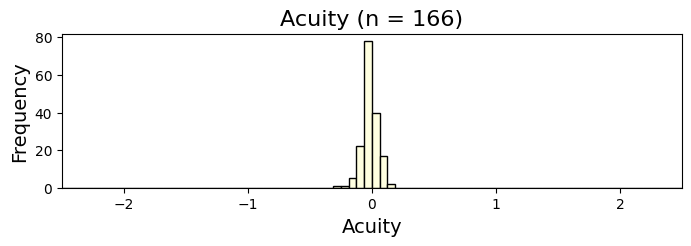

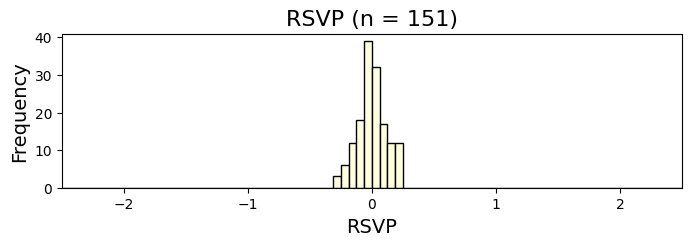

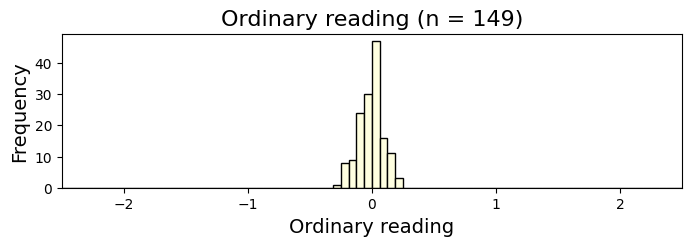

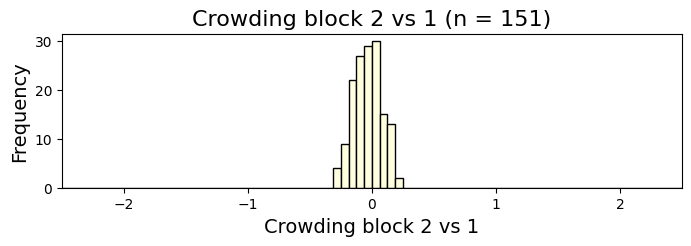

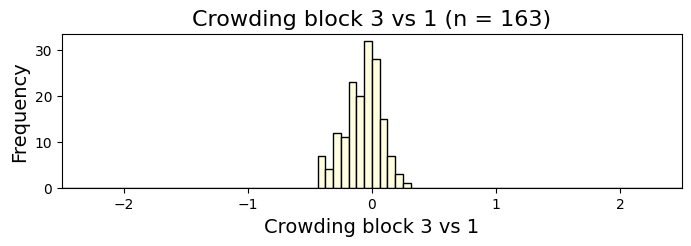

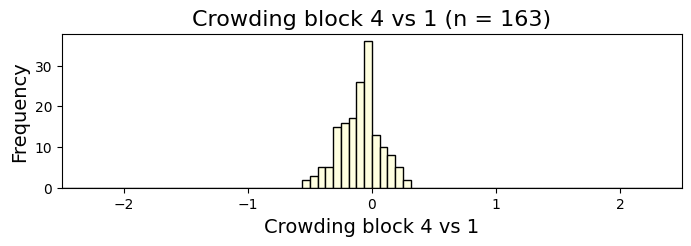

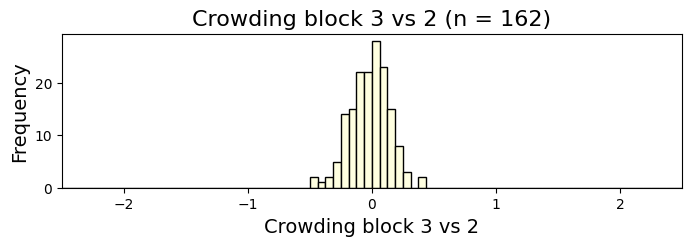

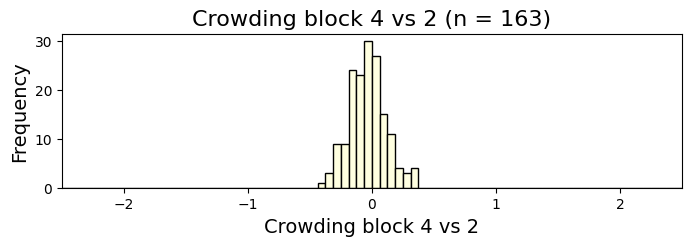

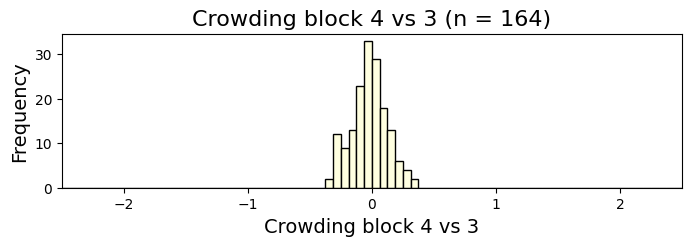

In [754]:
plot_ratio(df_filtered_acuity["log_ratio_2vs1"],title="Acuity")
plot_ratio(df_filtered_rsvp["log_ratio_2vs1"], title="RSVP")
plot_ratio(df_filtered_reading["log_ratio_2vs1"], title="Ordinary reading")

plot_ratio(df_filtered_crowding21["log_ratio_2vs1"], title="Crowding block 2 vs 1")
plot_ratio(df_filtered_crowding31["log_ratio_3vs1"], title="Crowding block 3 vs 1")
plot_ratio(df_filtered_crowding41["log_ratio_4vs1"], title="Crowding block 4 vs 1")
plot_ratio(df_filtered_crowding32["log_ratio_3vs2"], title="Crowding block 3 vs 2")
plot_ratio(df_filtered_crowding42["log_ratio_4vs2"], title="Crowding block 4 vs 2")
plot_ratio(df_filtered_crowding43["log_ratio_4vs3"], title="Crowding block 4 vs 3")

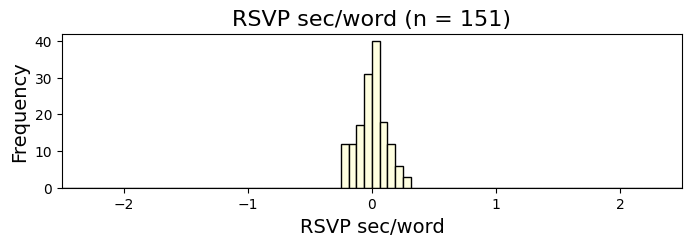

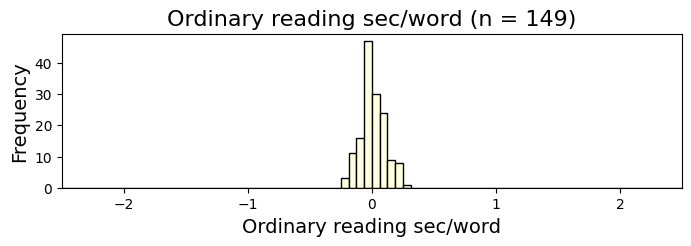

In [755]:
# SPW version: cleaned test-retest ratios for speed tasks
plot_ratio(log_ratio_wpm_to_spw(df_filtered_rsvp["log_ratio_2vs1"]), title="RSVP sec/word")
plot_ratio(log_ratio_wpm_to_spw(df_filtered_reading["log_ratio_2vs1"]), title="Ordinary reading sec/word")


## Save the list of participants being excluded

In [756]:
# merge and deduplicate
acuity_exclude_ids = list(set(acuity_low_trial_ids) 
                          | set(acuity_large_questSD_ids) 
                          | set(acuity_bad_ratio_ids))

crowding_exclude_ids = list(set(crowding_low_trial_ids) 
                          | set(crowding_large_questSD_ids) 
                          | set(crowding_bad_ratio_ids))

rsvp_exclude_ids = list(set(rsvp_low_trial_ids) 
                          | set(rsvp_large_questSD_ids) 
                          | set(rsvp_bad_ratio_ids))

reading_exclude_ids = list(set(reading_low_accuracy_ids) 
                          | set(reading_bad_ratio_ids))

exclude_dict = {
    "acuity": acuity_exclude_ids,
    "crowding": crowding_exclude_ids,
    "reading": reading_exclude_ids,
    "rsvp": rsvp_exclude_ids
}

import json

# with open("exclude_dict.json", "w") as f:
#     json.dump(exclude_dict, f, indent=2)


In [757]:
with open("exclude_dict.json", "r") as f:
    exclude_dict = json.load(f)

### Functions:

In [758]:
def plot_threshold_array(data_array, threshold_name, hist_color='skyblue', name_sd_bool=True,
                         num_bins=50, min_val=0.08, max_val=1.11, plot_JOV_patch=False):
    '''
    Input:
    - data_array: an array of data (could be output from extract_all_thresholds)
    - threshold_name: [string] title and x-axis label of the figure
    - plot_JOV_patch: [bool] plots mean +- 1 sd from crowding data (Kurzawski, Burchell et al., 2023, JOV) 
    - assuming all data are in log10 units, but we want to plot linear data on a log scale for ease of interpretation
      so we're going to unlog them first, before plotting
    '''
    
    # make the bins look the same size on a log scale
    # min_val = round(np.nanmin(data_array),2)
    # max_val = round(np.nanmax(data_array),2)
    # print(f'Min and max bin limits: {min_val}, {max_val}')
    data_array = 10**data_array
    std_data_array = np.nanstd(data_array)


    bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins + 1)

    plt.figure(figsize=(8, 2)) 

    if plot_JOV_patch:
        lowerBound = 0.18
        upperBound = 0.41
        plt.axvspan(lowerBound, upperBound, color='lightgray', alpha=0.5) # mean +- one std
    
    if name_sd_bool:
        plt.title(f"{threshold_name} (n = {np.count_nonzero(~np.isnan(data_array))}, sd = {round(std_data_array, 2)})", fontsize = 16)
    else:
        plt.title(f"{threshold_name} (n = {np.count_nonzero(~np.isnan(data_array))})", fontsize = 16)

    plt.hist(data_array, bins=bins, color=hist_color, edgecolor='black')
    plt.xlabel(threshold_name, fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(0.5, 200)

    # plt.xlim()
    # plt.ylim()
    # add ticks and format them as normal floats
    # tick_positions = np.logspace(np.log10(min_val), np.log10(max_val), num=10) if plot_log_scale else np.linspace(min_val, max_val, num=10)
    # plt.xticks(tick_positions, labels=[f"{x:.2f}" for x in tick_positions])
    
    plt.show()

In [759]:
def plot_hist_task(df, taskName, y_value,
                    low_trial_ids, large_questSD_ids, bad_ratio_ids, num_bins=50, min_val=0.5, max_val=10, bouma_bool=False):
    '''
    Plot histograms for raw data, low trial data, large questSD data, bad ratio data, and cleaned data for a given task.
    '''
    df_task_raw = df[df['taskName'] == taskName]
    df_low_trial = filter_including_ids(df_task_raw, low_trial_ids)
    df_large_questSD = filter_including_ids(df_task_raw, large_questSD_ids)
    df_bad_ratio = filter_including_ids(df_task_raw, bad_ratio_ids)
    df_cleaned = filter_excluding_ids(df_task_raw, low_trial_ids, large_questSD_ids, bad_ratio_ids)
    display(df_cleaned.head())

    raw_thresholds = df_task_raw[y_value]
    low_trial_thresholds = df_low_trial[y_value]
    large_questSD_thresholds = df_large_questSD[y_value]
    bad_ratio_thresholds = df_bad_ratio[y_value]
    cleaned_thresholds = df_cleaned[y_value]

    # if bouma_bool:
    #     raw_thresholds = raw_thresholds / 8
    #     low_trial_thresholds = low_trial_thresholds / 8
    #     large_questSD_thresholds = large_questSD_thresholds / 8
    #     bad_ratio_thresholds = bad_ratio_thresholds / 8
    #     cleaned_thresholds = cleaned_thresholds / 8

    df_summary_stats = pd.DataFrame([{
        'task_name' : taskName,
        'n_cleaned' : len(cleaned_thresholds),
        'geomean_cleaned' : 10 ** np.mean(cleaned_thresholds),
        'median_cleaned' : 10 ** np.median(cleaned_thresholds),
        'min_cleaned' : 10 ** np.min(cleaned_thresholds),
        'max_cleaned' : 10 ** np.max(cleaned_thresholds),
        'sd_of_log_cleaned' : np.std(cleaned_thresholds)
    }])
    display(df_summary_stats)

    plot_threshold_array(raw_thresholds, f'{taskName} raw', num_bins=num_bins, min_val=min_val, max_val=max_val)
    plot_threshold_array(low_trial_thresholds, f'{taskName} low trials', num_bins=num_bins, min_val=min_val, max_val=max_val, hist_color='plum', name_sd_bool=False)
    plot_threshold_array(large_questSD_thresholds, f'{taskName} large questSD', num_bins=num_bins, min_val=min_val, max_val=max_val, hist_color='plum', name_sd_bool=False)
    plot_threshold_array(bad_ratio_thresholds, f'{taskName} bad test-retest ratio', num_bins=num_bins, min_val=min_val, max_val=max_val, hist_color='plum', name_sd_bool=False)
    plot_threshold_array(cleaned_thresholds, f'{taskName} cleaned', num_bins=num_bins, min_val=min_val, max_val=max_val)

    return df_summary_stats

### All individual thresholds:

,prolificID,conditionName,taskName,meridian,repeat,threshold,numTrialsSent,questSD,readingCQAccuracy
4,5f0788c06b220f03231666a0,acuity_R8_block1,acuity,R8,1,-0.472122,36.0,0.048382,NaN
5,5f0788c06b220f03231666a0,acuity_L8_block1,acuity,L8,1,-0.477837,35.0,0.049845,NaN
16,6778842e3f7e2e62756f7178,acuity_R8_block1,acuity,R8,1,-0.292501,35.0,0.049994,NaN
17,6778842e3f7e2e62756f7178,acuity_L8_block1,acuity,L8,1,-0.436618,36.0,0.047824,NaN
22,5e57d38b533eec1818078f0b,acuity_R8_block1,acuity,R8,1,-0.499952,36.0,0.049817,NaN


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,acuity,604,0.315941,0.310445,0.146709,0.617451,0.088911


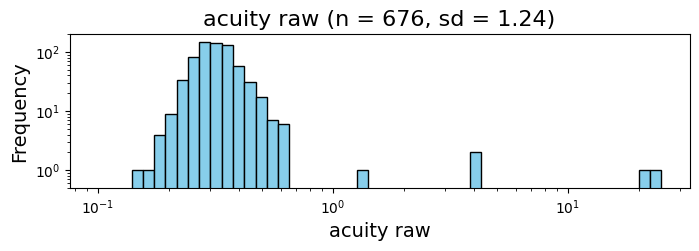

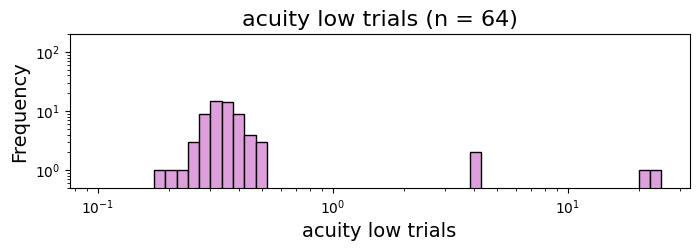

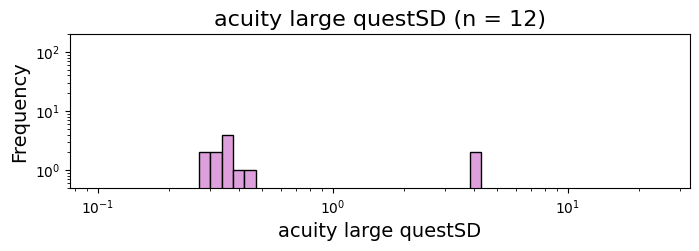

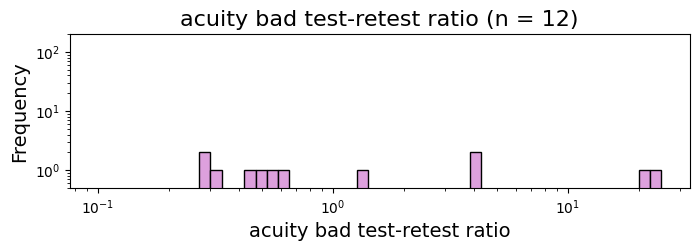

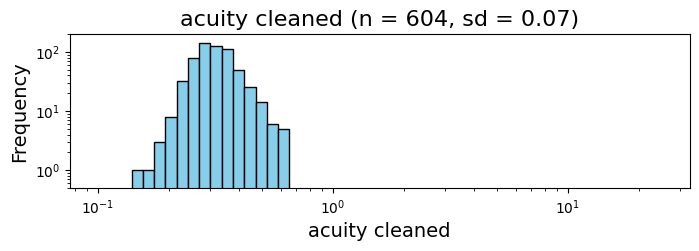

,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,acuity,604,0.315941,0.310445,0.146709,0.617451,0.088911


In [760]:
plot_hist_task(df_both_sessions, 'acuity', 'threshold',
                acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids, 
                num_bins=50, min_val=0.1, max_val=25)

,prolificID,conditionName,taskName,meridian,repeat,threshold,numTrialsSent,questSD,readingCQAccuracy
18,5e57d38b533eec1818078f0b,crowding_R8_block1,crowding,R8,1,0.518647,36.0,0.048975,NaN
19,5e57d38b533eec1818078f0b,crowding_L8_block1,crowding,L8,1,0.504546,36.0,0.047107,NaN
20,5e57d38b533eec1818078f0b,crowding_R8_block2,crowding,R8,2,0.512413,36.0,0.047961,NaN
21,5e57d38b533eec1818078f0b,crowding_L8_block2,crowding,L8,2,0.402477,37.0,0.058266,NaN
36,63174af7d57182f9bf90c094,crowding_R8_block1,crowding,R8,1,0.629552,36.0,0.057636,NaN


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,crowding,864,2.38713,2.563679,0.324394,18.284052,0.24262


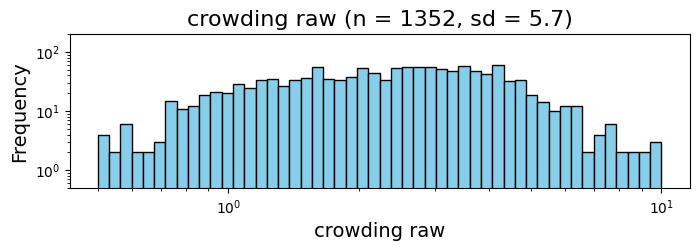

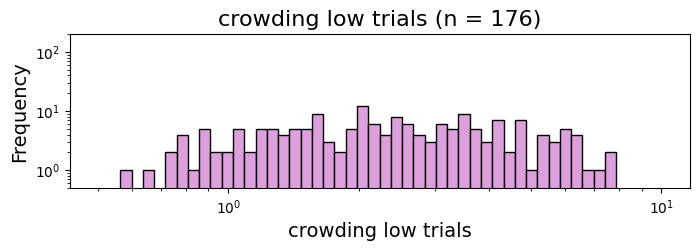

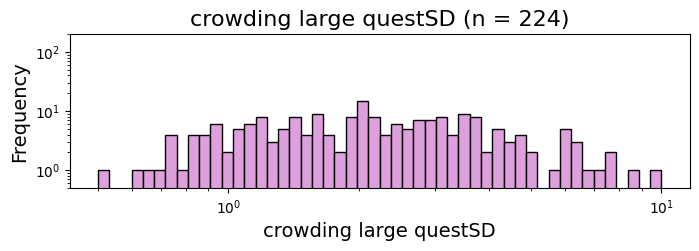

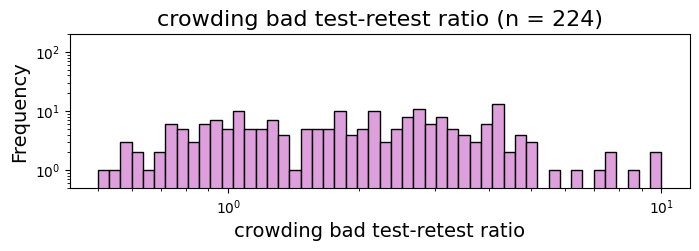

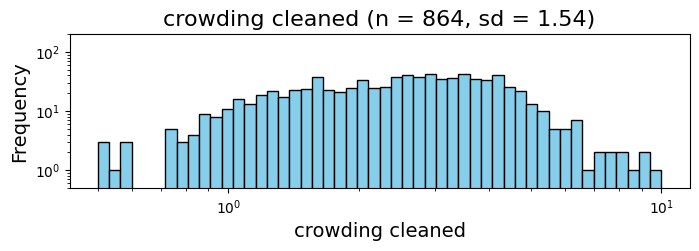

In [761]:
# crowding
summary_crowding_all_thresh = plot_hist_task(df_both_sessions, 'crowding', 'threshold',
                                             crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)

,prolificID,conditionName,taskName,meridian,repeat,threshold,numTrialsSent,questSD,readingCQAccuracy
1014,5f0788c06b220f03231666a0,rsvp_foveal_block1,rsvp,foveal,1,3.263004,25.0,0.031329,NaN
1015,64837ba51422d817b62cc5cc,rsvp_foveal_block1,rsvp,foveal,1,3.370150,25.0,0.031303,NaN
1016,6778842e3f7e2e62756f7178,rsvp_foveal_block1,rsvp,foveal,1,3.380842,25.0,0.031597,NaN
1017,5e57d38b533eec1818078f0b,rsvp_foveal_block1,rsvp,foveal,1,3.111377,25.0,0.031854,NaN
1018,6501b789e3ddbc0a0b79b925,rsvp_foveal_block1,rsvp,foveal,1,3.331373,25.0,0.030943,NaN


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,288,1463.680337,1557.161182,333.871474,3045.424347,0.190614


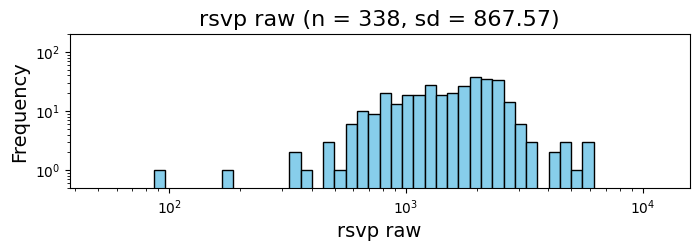

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/cw/__v4n9dd1cl59tk5n02vqjg5lj9bck/T/ipykernel_2202/2176313673.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


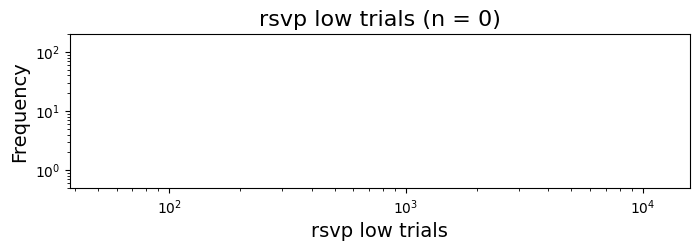

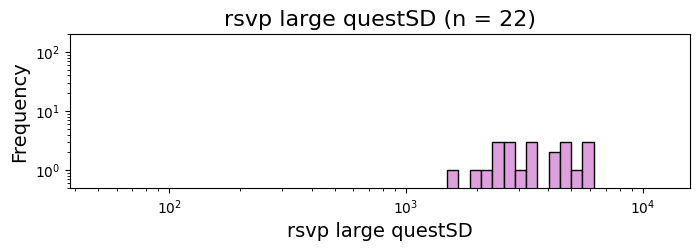

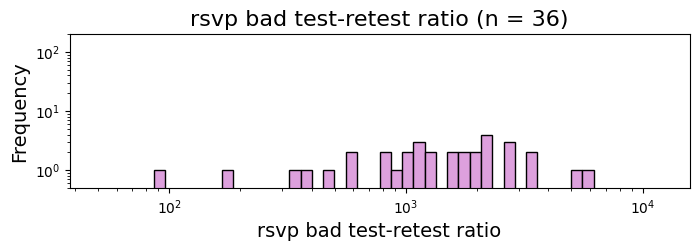

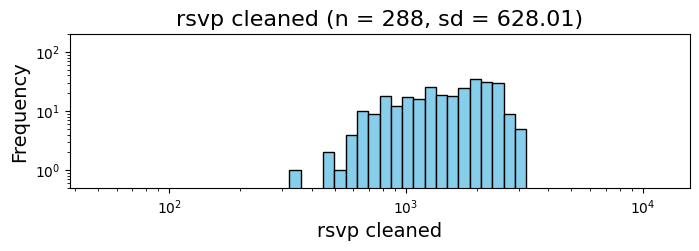

In [762]:
# rsvp
df_summary_rsvp_allthresh = plot_hist_task(df_both_sessions, 'rsvp', 'threshold',
                                            rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids, 
                                            num_bins=50, min_val=50, max_val=12000)

,prolificID,conditionName,taskName,meridian,repeat,threshold,numTrialsSent,questSD,readingCQAccuracy
1014,5f0788c06b220f03231666a0,rsvp_foveal_block1,rsvp,foveal,1,-1.484853,25.0,0.031329,NaN
1015,64837ba51422d817b62cc5cc,rsvp_foveal_block1,rsvp,foveal,1,-1.591999,25.0,0.031303,NaN
1016,6778842e3f7e2e62756f7178,rsvp_foveal_block1,rsvp,foveal,1,-1.602691,25.0,0.031597,NaN
1017,5e57d38b533eec1818078f0b,rsvp_foveal_block1,rsvp,foveal,1,-1.333225,25.0,0.031854,NaN
1018,6501b789e3ddbc0a0b79b925,rsvp_foveal_block1,rsvp,foveal,1,-1.553222,25.0,0.030943,NaN


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,288,0.040993,0.038532,0.019702,0.17971,0.190614


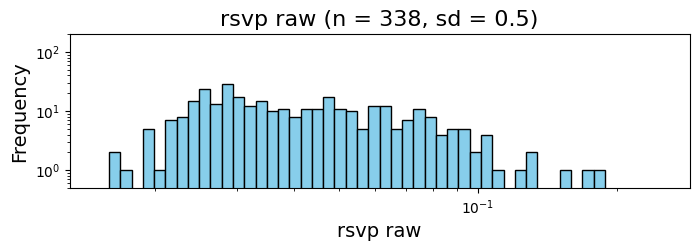

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/cw/__v4n9dd1cl59tk5n02vqjg5lj9bck/T/ipykernel_2202/2176313673.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


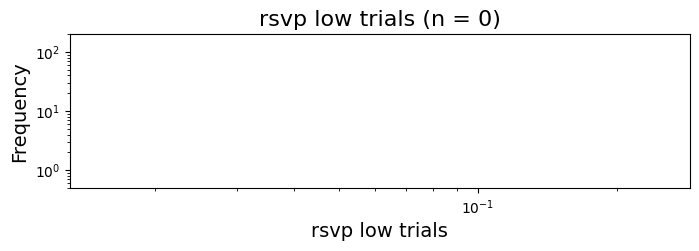

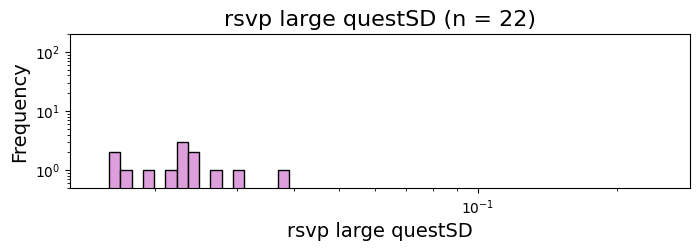

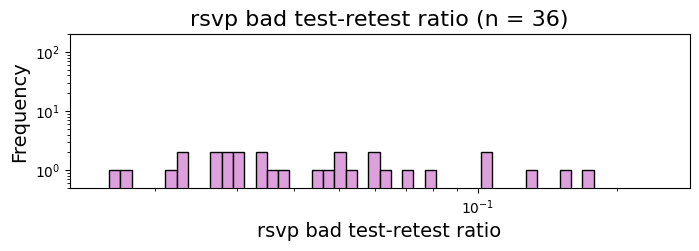

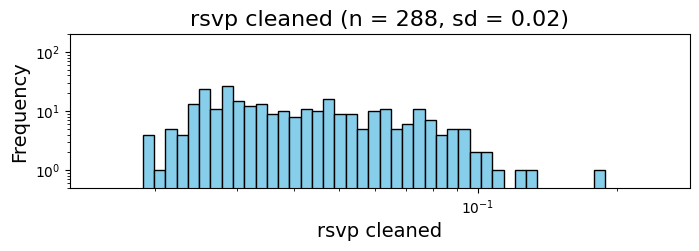

In [763]:
# SPW version
rsvp_both_sessions_spw = with_log_spw(df_both_sessions, 'threshold')
df_summary_rsvp_allthresh_spw = plot_hist_task(
    rsvp_both_sessions_spw, 'rsvp', 'threshold',
    rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids,
    num_bins=50, min_val=0.015, max_val=0.25
)


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_logged_cleaned
0,reading_individual_measurements,404,239.087773,238.555167,60.152601,2251.407129,0.183697


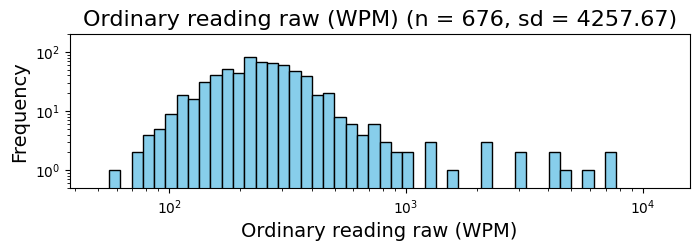

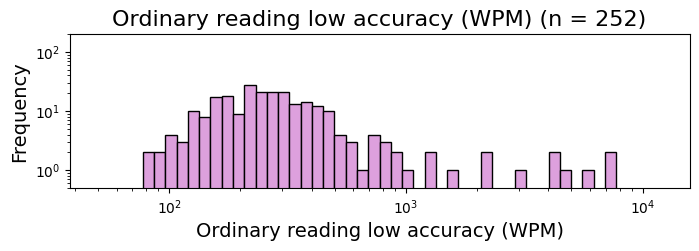

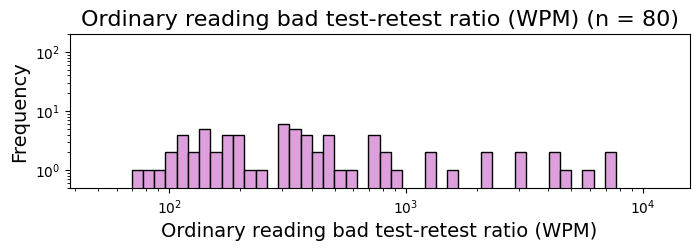

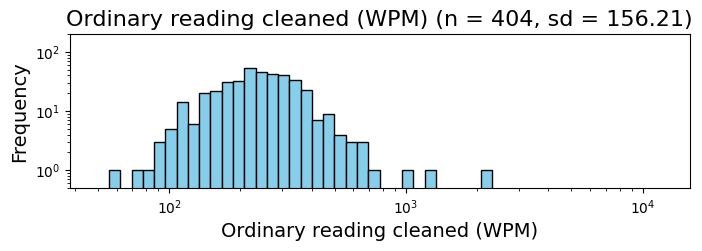

In [764]:
# ordinary reading
df_reading_allThresh_raw = df_both_sessions[df_both_sessions['taskName'] == 'reading']
df_reading_allThresh_low_trial = filter_including_ids(df_reading_allThresh_raw, reading_low_accuracy_ids)
df_reading_allThresh_bad_ratio = filter_including_ids(df_reading_allThresh_raw, reading_bad_ratio_ids)
df_reading_allThresh_cleaned = filter_excluding_ids(df_reading_allThresh_raw, reading_low_accuracy_ids, reading_bad_ratio_ids)

df_summary_reading_allThresh = pd.DataFrame([{
    'task_name' : 'reading_individual_measurements',
    'n_cleaned' : len(df_reading_allThresh_cleaned['threshold']),
    'geomean_cleaned' : 10 ** np.mean(df_reading_allThresh_cleaned['threshold']),
    'median_cleaned' : 10 ** np.median(df_reading_allThresh_cleaned['threshold']),
    'min_cleaned' : 10 ** np.min(df_reading_allThresh_cleaned['threshold']),
    'max_cleaned' : 10 ** np.max(df_reading_allThresh_cleaned['threshold']),
    'sd_of_logged_cleaned' : np.std(df_reading_allThresh_cleaned['threshold'])
}])
display(df_summary_reading_allThresh)

plot_threshold_array(df_reading_allThresh_raw['threshold'], 'Ordinary reading raw (WPM)', num_bins=50, min_val=50, max_val=12000)
plot_threshold_array(df_reading_allThresh_low_trial['threshold'], 'Ordinary reading low accuracy (WPM)', num_bins=50, min_val=50, max_val=12000, hist_color='plum', name_sd_bool=False)
plot_threshold_array(df_reading_allThresh_bad_ratio['threshold'], 'Ordinary reading bad test-retest ratio (WPM)', num_bins=50, min_val=50, max_val=12000, hist_color='plum', name_sd_bool=False)
plot_threshold_array(df_reading_allThresh_cleaned['threshold'], 'Ordinary reading cleaned (WPM)', num_bins=50, min_val=50, max_val=12000)

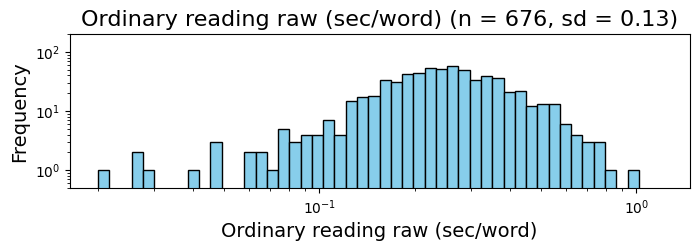

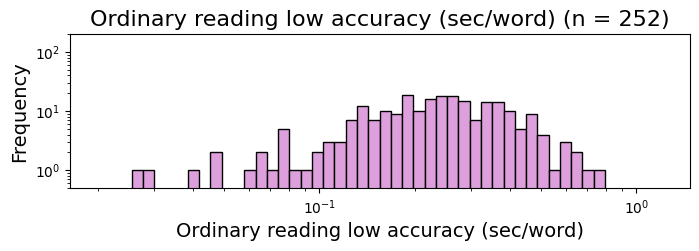

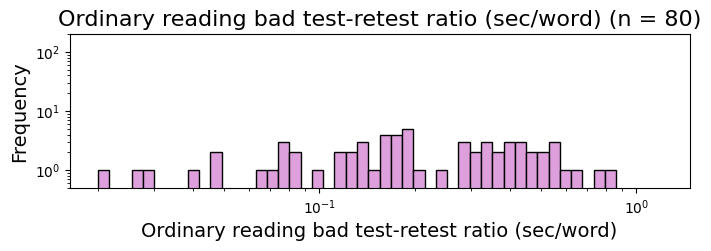

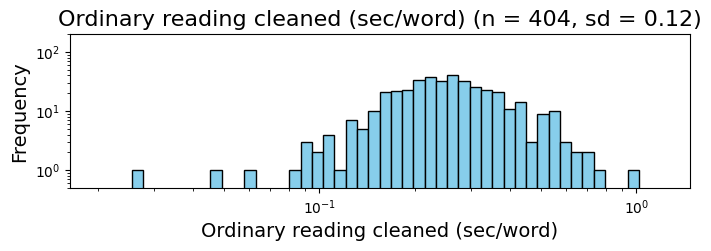

In [765]:
# SPW version
plot_threshold_array(log_wpm_to_log_spw(df_reading_allThresh_raw['threshold']), 'Ordinary reading raw (sec/word)', num_bins=50, min_val=0.02, max_val=1.2)
plot_threshold_array(log_wpm_to_log_spw(df_reading_allThresh_low_trial['threshold']), 'Ordinary reading low accuracy (sec/word)', num_bins=50, min_val=0.02, max_val=1.2, hist_color='plum', name_sd_bool=False)
plot_threshold_array(log_wpm_to_log_spw(df_reading_allThresh_bad_ratio['threshold']), 'Ordinary reading bad test-retest ratio (sec/word)', num_bins=50, min_val=0.02, max_val=1.2, hist_color='plum', name_sd_bool=False)
plot_threshold_array(log_wpm_to_log_spw(df_reading_allThresh_cleaned['threshold']), 'Ordinary reading cleaned (sec/word)', num_bins=50, min_val=0.02, max_val=1.2)


### Geomean for each block

,prolificID,taskName,repeat,gmean_threshold_block
0,559ad287fdf99b219a612d22,acuity,1,-0.415187
1,559ad287fdf99b219a612d22,acuity,2,-0.480609
10,55d51a6b8ce09000127d4821,acuity,1,-0.596659
11,55d51a6b8ce09000127d4821,acuity,2,-0.670809
20,5685850c333cbd000d4e042f,acuity,1,-0.494388


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,acuity,302,0.315941,0.310311,0.166444,0.607752,0.080242


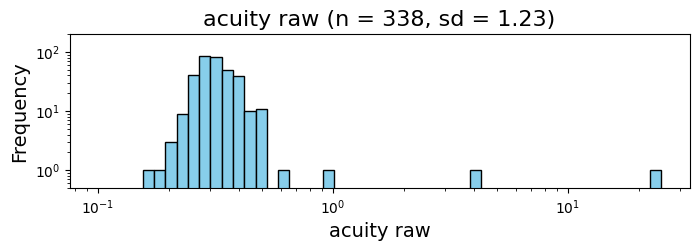

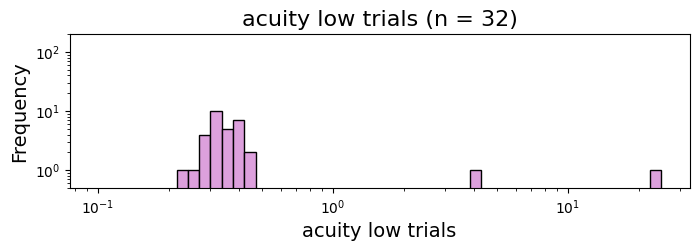

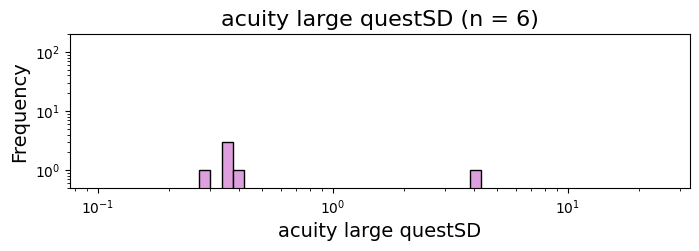

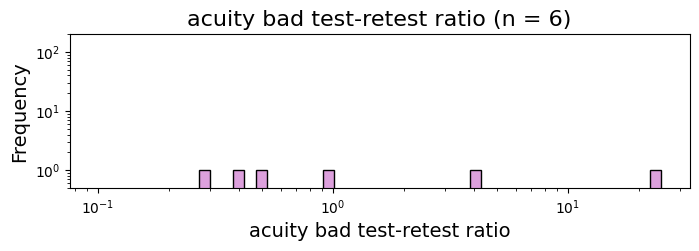

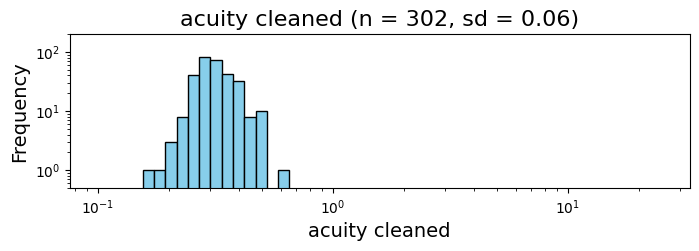

,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,acuity,302,0.315941,0.310311,0.166444,0.607752,0.080242


In [766]:
plot_hist_task(df_gmean_block, 'acuity', 'gmean_threshold_block',
                acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids, 
                num_bins=50, min_val=0.1, max_val=25)

,prolificID,taskName,repeat,gmean_threshold_block
2,559ad287fdf99b219a612d22,crowding,1,0.845687
3,559ad287fdf99b219a612d22,crowding,2,0.882659
4,559ad287fdf99b219a612d22,crowding,3,0.950354
5,559ad287fdf99b219a612d22,crowding,4,1.040760
12,55d51a6b8ce09000127d4821,crowding,1,0.089592


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,crowding,432,2.38713,2.465265,0.369612,10.983982,0.20345


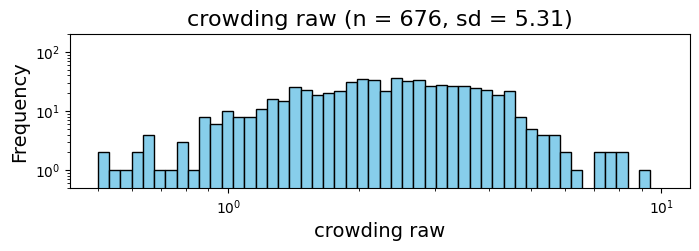

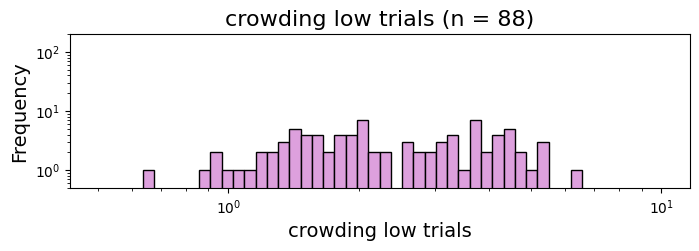

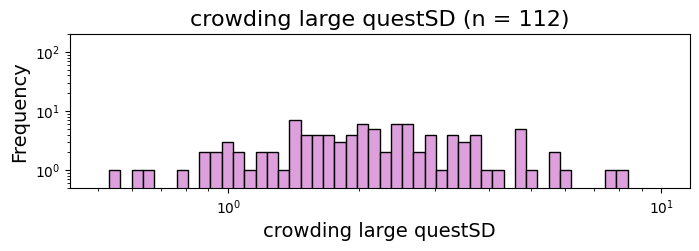

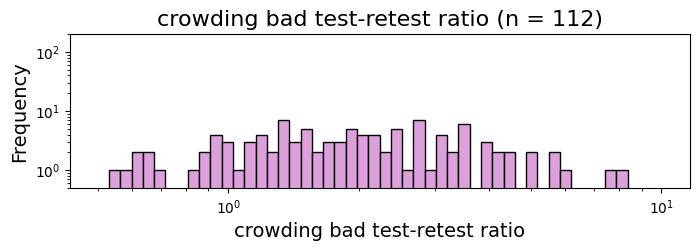

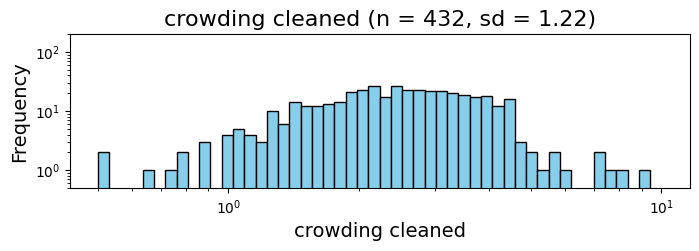

In [767]:
# crowding
summary_crowding_block = plot_hist_task(df_gmean_block, 'crowding', 'gmean_threshold_block',
                                                crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)

,prolificID,taskName,repeat,gmean_threshold_block
8,559ad287fdf99b219a612d22,rsvp,1,2.523579
9,559ad287fdf99b219a612d22,rsvp,2,2.742889
28,5685850c333cbd000d4e042f,rsvp,1,3.252130
29,5685850c333cbd000d4e042f,rsvp,2,3.274171
38,56b78f11e77ebe000cbefe79,rsvp,1,3.038510


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,288,1463.680337,1557.161182,333.871474,3045.424347,0.190614


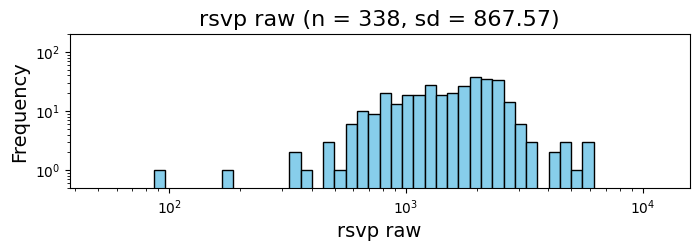

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/cw/__v4n9dd1cl59tk5n02vqjg5lj9bck/T/ipykernel_2202/2176313673.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


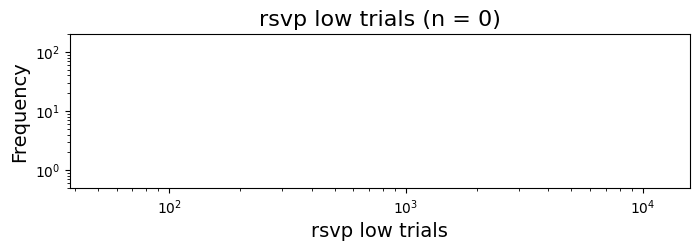

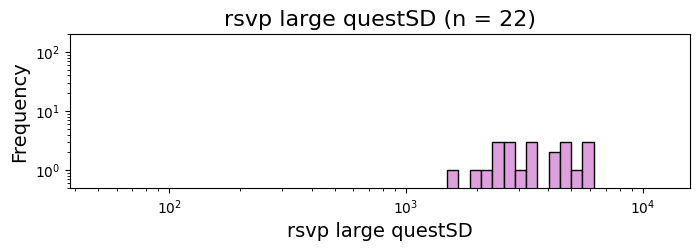

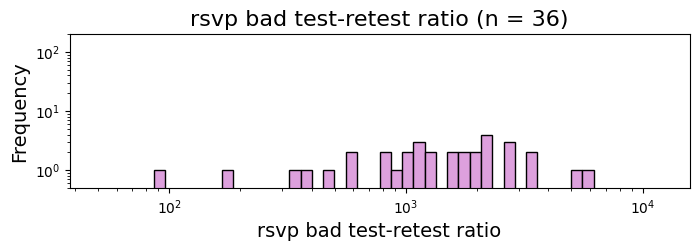

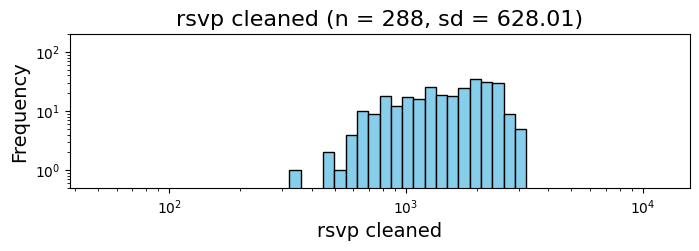

In [768]:
# rsvp
df_summary_rsvp_block = plot_hist_task(df_gmean_block, 'rsvp', 'gmean_threshold_block', 
                                        rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids, 
                                        num_bins=50, min_val=50, max_val=12000)

,prolificID,taskName,repeat,gmean_threshold_block
8,559ad287fdf99b219a612d22,rsvp,1,-0.745428
9,559ad287fdf99b219a612d22,rsvp,2,-0.964738
28,5685850c333cbd000d4e042f,rsvp,1,-1.473979
29,5685850c333cbd000d4e042f,rsvp,2,-1.496020
38,56b78f11e77ebe000cbefe79,rsvp,1,-1.260359


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,288,0.040993,0.038532,0.019702,0.17971,0.190614


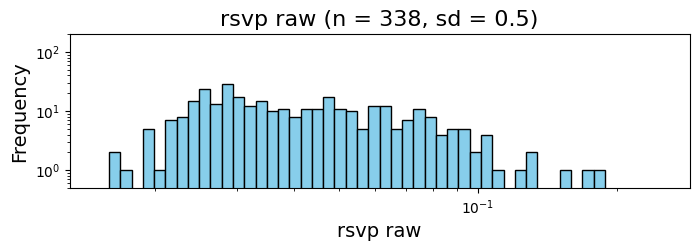

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/cw/__v4n9dd1cl59tk5n02vqjg5lj9bck/T/ipykernel_2202/2176313673.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


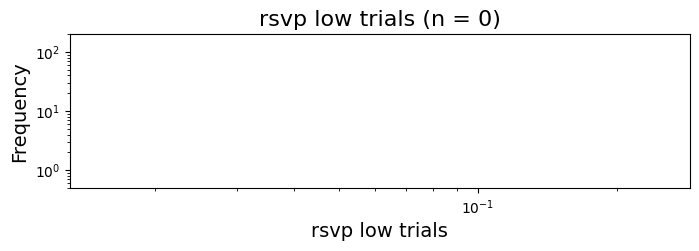

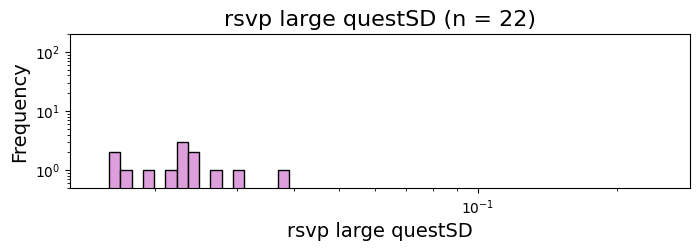

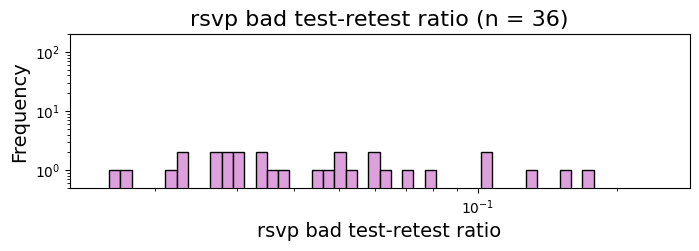

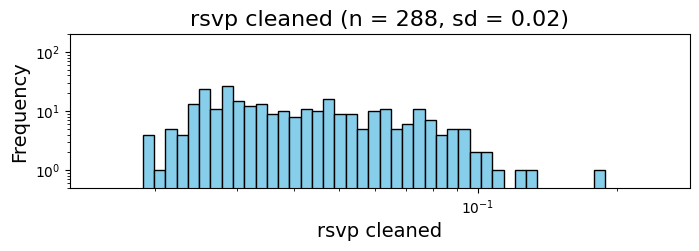

In [769]:
# SPW version
rsvp_gmean_block_spw = with_log_spw(df_gmean_block, 'gmean_threshold_block')
df_summary_rsvp_block_spw = plot_hist_task(
    rsvp_gmean_block_spw, 'rsvp', 'gmean_threshold_block',
    rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids,
    num_bins=50, min_val=0.015, max_val=0.25
)


,prolificID,taskName,repeat,gmean_threshold_block
6,559ad287fdf99b219a612d22,reading,1,2.322498
7,559ad287fdf99b219a612d22,reading,2,2.234990
16,55d51a6b8ce09000127d4821,reading,1,2.398362
17,55d51a6b8ce09000127d4821,reading,2,2.281513
26,5685850c333cbd000d4e042f,reading,1,2.344673


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_logged_cleaned
0,reading_per_block,202,239.087773,242.583019,96.19204,1160.985106,0.16494


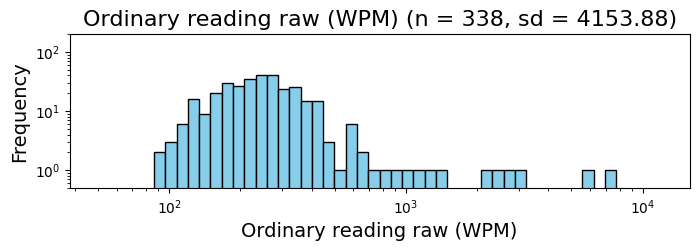

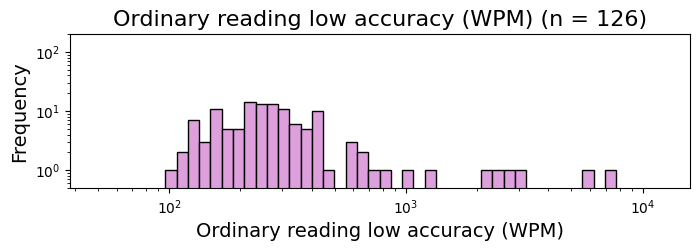

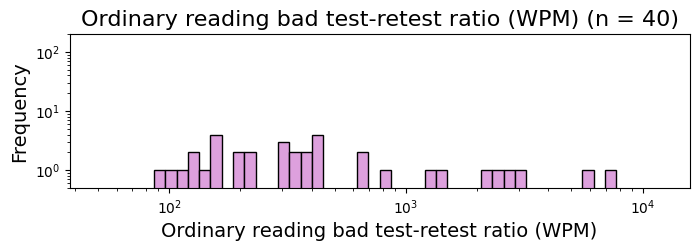

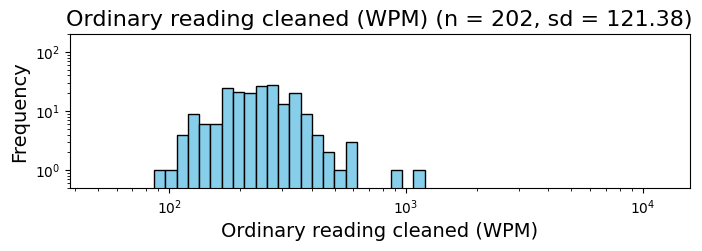

In [770]:
# ordinary reading
df_reading_gmean_block_raw = df_gmean_block[df_gmean_block['taskName'] == 'reading']
df_reading_gmean_block_low_trial = filter_including_ids(df_reading_gmean_block_raw, reading_low_accuracy_ids)
df_reading_gmean_block_bad_ratio = filter_including_ids(df_reading_gmean_block_raw, reading_bad_ratio_ids)
df_reading_gmean_block_cleaned = filter_excluding_ids(df_reading_gmean_block_raw, reading_low_accuracy_ids, reading_bad_ratio_ids)
display(df_reading_gmean_block_cleaned.head())

df_summary_reading_geomean_block = pd.DataFrame([{
    'task_name' : 'reading_per_block',
    'n_cleaned' : len(df_reading_gmean_block_cleaned['gmean_threshold_block']),
    'geomean_cleaned' : 10 ** np.mean(df_reading_gmean_block_cleaned['gmean_threshold_block']),
    'median_cleaned' : 10 ** np.median(df_reading_gmean_block_cleaned['gmean_threshold_block']),
    'min_cleaned' : 10 ** np.min(df_reading_gmean_block_cleaned['gmean_threshold_block']),
    'max_cleaned' : 10 ** np.max(df_reading_gmean_block_cleaned['gmean_threshold_block']),
    'sd_of_logged_cleaned' : np.std(df_reading_gmean_block_cleaned['gmean_threshold_block'])
}])
display(df_summary_reading_geomean_block)


plot_threshold_array(df_reading_gmean_block_raw['gmean_threshold_block'], 'Ordinary reading raw (WPM)', num_bins=50, min_val=50, max_val=12000)
plot_threshold_array(df_reading_gmean_block_low_trial['gmean_threshold_block'], 'Ordinary reading low accuracy (WPM)', num_bins=50, min_val=50, max_val=12000, hist_color='plum', name_sd_bool=False)
plot_threshold_array(df_reading_gmean_block_bad_ratio['gmean_threshold_block'], 'Ordinary reading bad test-retest ratio (WPM)', num_bins=50, min_val=50, max_val=12000, hist_color='plum', name_sd_bool=False)
plot_threshold_array(df_reading_gmean_block_cleaned['gmean_threshold_block'], 'Ordinary reading cleaned (WPM)', num_bins=50, min_val=50, max_val=12000)

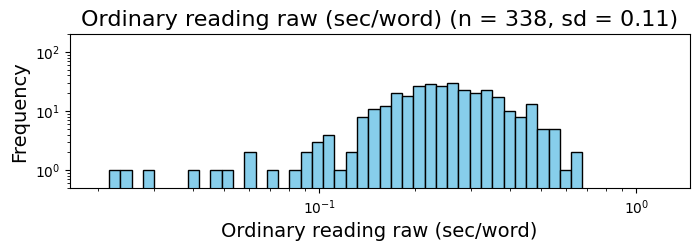

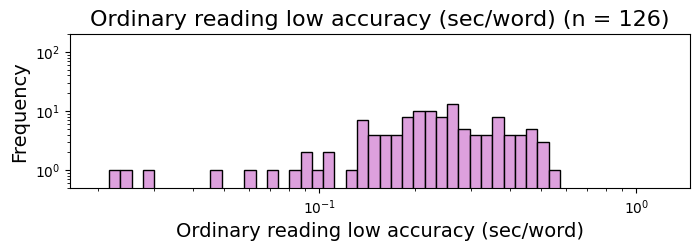

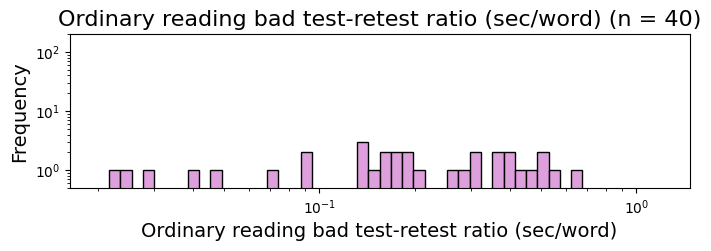

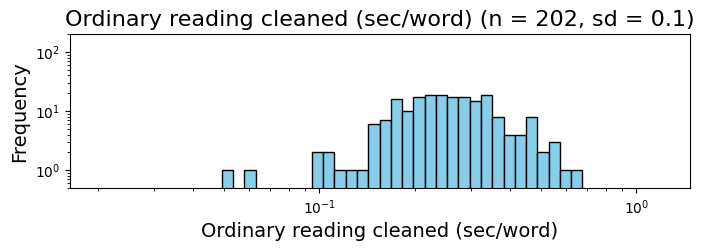

In [771]:
# SPW version
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_block_raw['gmean_threshold_block']), 'Ordinary reading raw (sec/word)', num_bins=50, min_val=0.02, max_val=1.2)
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_block_low_trial['gmean_threshold_block']), 'Ordinary reading low accuracy (sec/word)', num_bins=50, min_val=0.02, max_val=1.2, hist_color='plum', name_sd_bool=False)
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_block_bad_ratio['gmean_threshold_block']), 'Ordinary reading bad test-retest ratio (sec/word)', num_bins=50, min_val=0.02, max_val=1.2, hist_color='plum', name_sd_bool=False)
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_block_cleaned['gmean_threshold_block']), 'Ordinary reading cleaned (sec/word)', num_bins=50, min_val=0.02, max_val=1.2)


### Geomean for each task:

,prolificID,taskName,gmean_threshold_task
0,559ad287fdf99b219a612d22,acuity,-0.447898
4,55d51a6b8ce09000127d4821,acuity,-0.633734
8,5685850c333cbd000d4e042f,acuity,-0.517487
12,56b78f11e77ebe000cbefe79,acuity,-0.451985
16,57334d427d01ed00098e8e69,acuity,-0.539654


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,acuity,151,0.315941,0.309725,0.17555,0.561669,0.073915


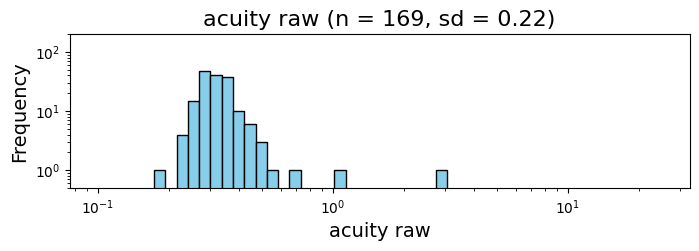

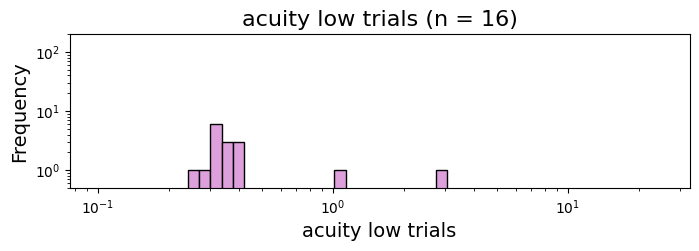

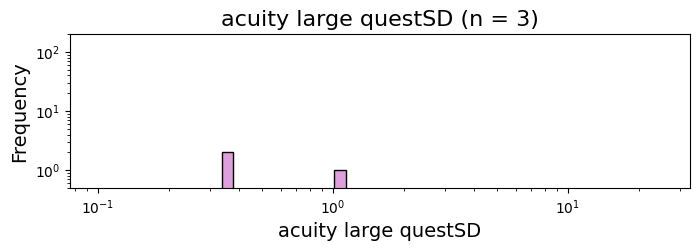

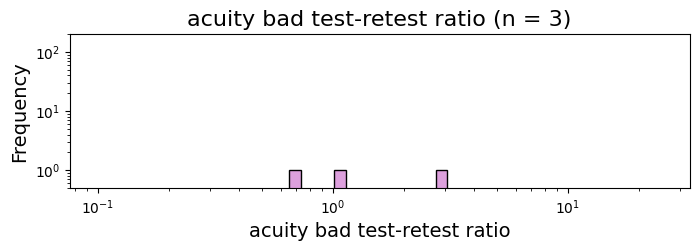

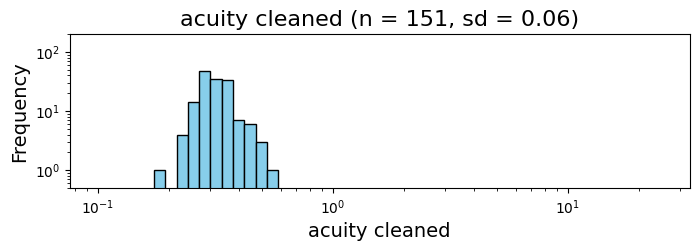

,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,acuity,151,0.315941,0.309725,0.17555,0.561669,0.073915


In [772]:
plot_hist_task(df_gmean_task, 'acuity', 'gmean_threshold_task',
                acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids, 
                num_bins=50, min_val=0.1, max_val=25)

,prolificID,taskName,gmean_threshold_task
1,559ad287fdf99b219a612d22,crowding,0.929865
5,55d51a6b8ce09000127d4821,crowding,0.036757
17,57334d427d01ed00098e8e69,crowding,0.225920
21,581bd344930a280001062c90,crowding,0.334971
33,588ab33542c8e900019d02ae,crowding,0.077324


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,crowding,108,2.38713,2.388704,0.502819,8.508733,0.185039


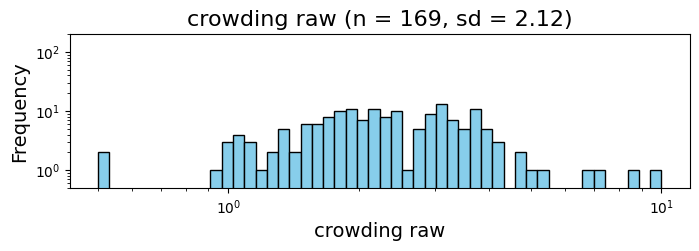

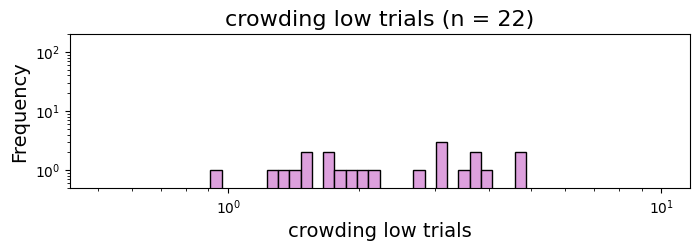

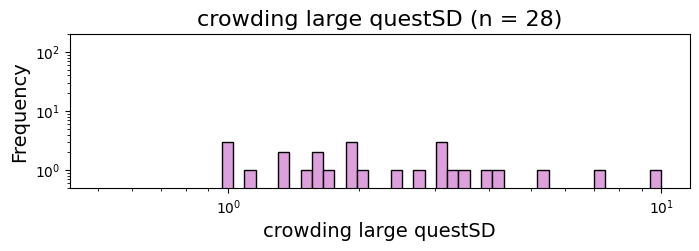

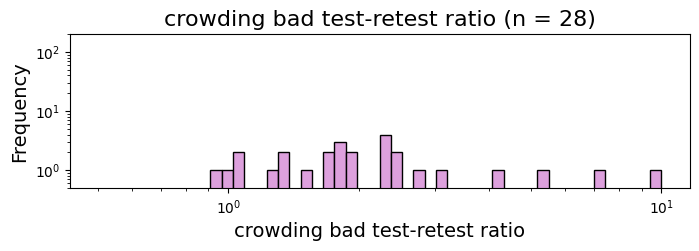

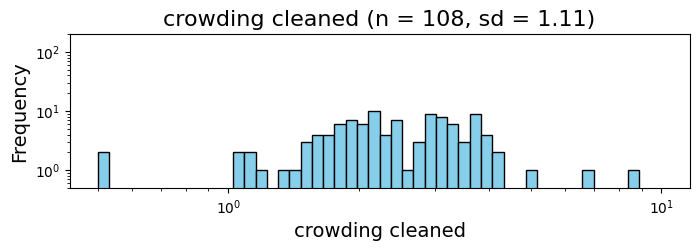

In [773]:
# crowding
summary_crowding_task = plot_hist_task(df_gmean_task, 'crowding', 'gmean_threshold_task',
                                        crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)

,prolificID,taskName,gmean_threshold_task
3,559ad287fdf99b219a612d22,rsvp,2.633234
11,5685850c333cbd000d4e042f,rsvp,3.263151
15,56b78f11e77ebe000cbefe79,rsvp,3.144948
19,57334d427d01ed00098e8e69,rsvp,3.147468
23,581bd344930a280001062c90,rsvp,3.217009


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,144,1463.680337,1611.097598,429.768011,2933.259564,0.182752


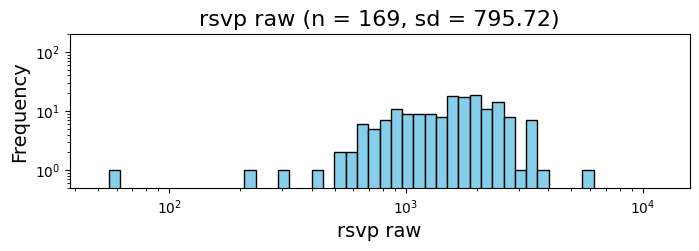

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/cw/__v4n9dd1cl59tk5n02vqjg5lj9bck/T/ipykernel_2202/2176313673.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


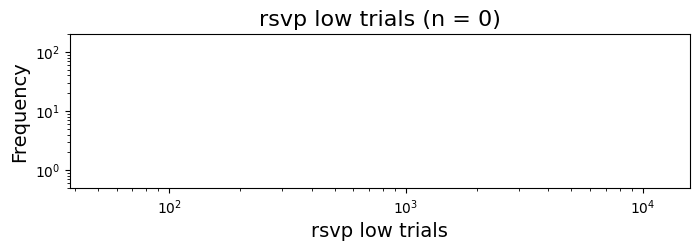

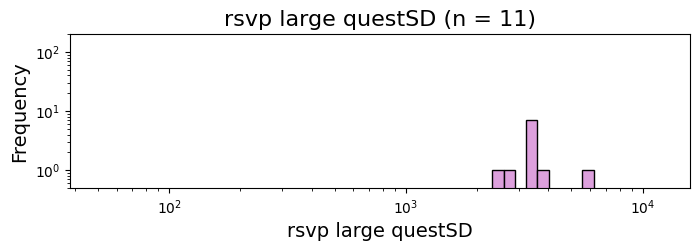

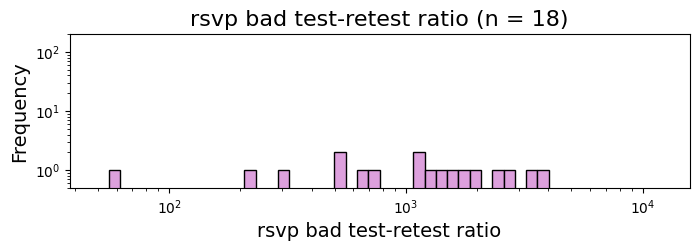

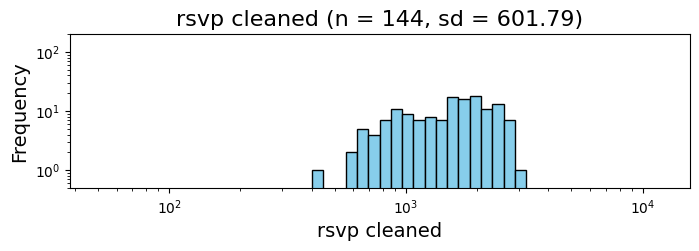

In [774]:
# rsvp
df_summary_rsvp_task = plot_hist_task(df_gmean_task, 'rsvp', 'gmean_threshold_task', 
                                        rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids, 
                                        num_bins=50, min_val=50, max_val=12000)

,prolificID,taskName,gmean_threshold_task
3,559ad287fdf99b219a612d22,rsvp,-0.855083
11,5685850c333cbd000d4e042f,rsvp,-1.484999
15,56b78f11e77ebe000cbefe79,rsvp,-1.366797
19,57334d427d01ed00098e8e69,rsvp,-1.369316
23,581bd344930a280001062c90,rsvp,-1.438857


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,144,0.040993,0.037242,0.020455,0.13961,0.182752


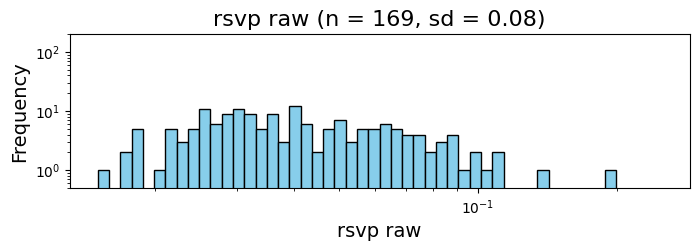

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/cw/__v4n9dd1cl59tk5n02vqjg5lj9bck/T/ipykernel_2202/2176313673.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


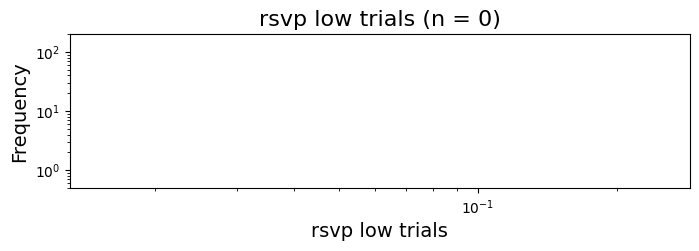

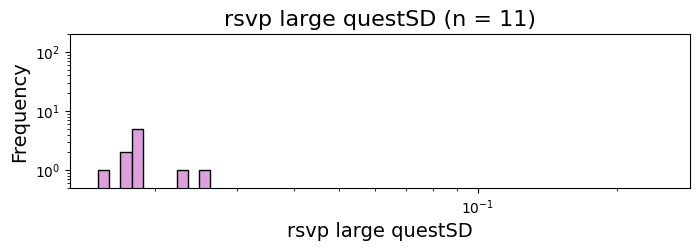

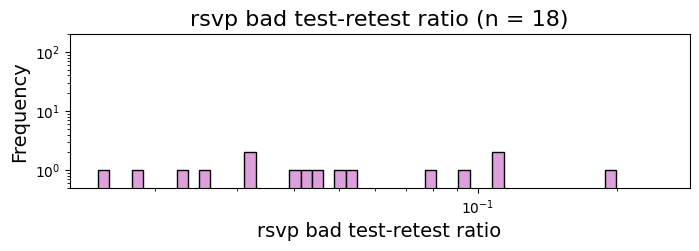

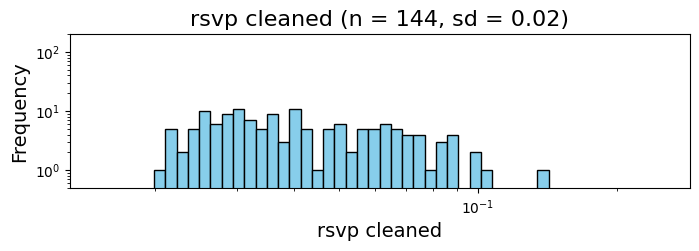

In [775]:
# SPW version
rsvp_gmean_task_spw = with_log_spw(df_gmean_task, 'gmean_threshold_task')
df_summary_rsvp_task_spw = plot_hist_task(
    rsvp_gmean_task_spw, 'rsvp', 'gmean_threshold_task',
    rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids,
    num_bins=50, min_val=0.015, max_val=0.25
)


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_logged_cleaned
0,reading_per_task,101,239.087773,232.151054,102.993237,846.186631,0.158453


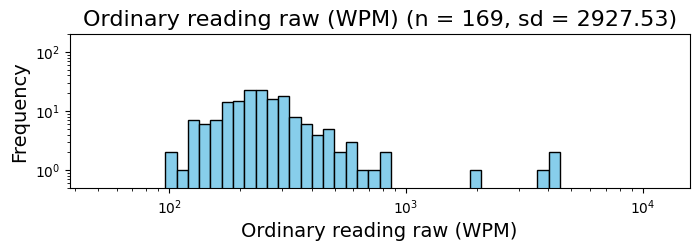

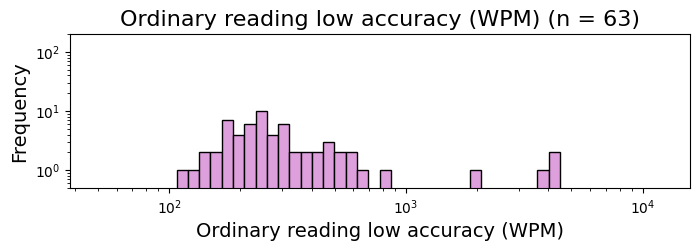

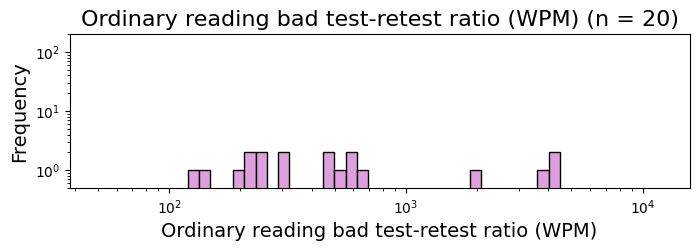

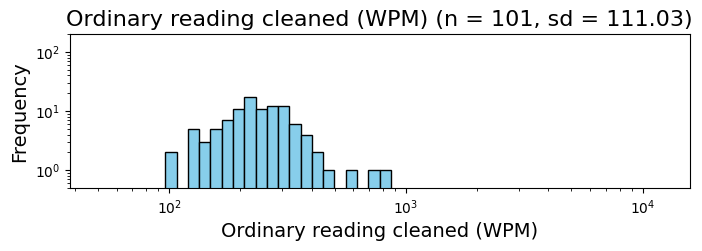

In [776]:
# ordinary reading
df_reading_gmean_task_raw = df_gmean_task[df_gmean_task['taskName'] == 'reading']
df_reading_gmean_task_low_trial = filter_including_ids(df_reading_gmean_task_raw, reading_low_accuracy_ids)
df_reading_gmean_task_bad_ratio = filter_including_ids(df_reading_gmean_task_raw, reading_bad_ratio_ids)
df_reading_gmean_task_cleaned = filter_excluding_ids(df_reading_gmean_task_raw, reading_low_accuracy_ids, reading_bad_ratio_ids)

df_summary_reading_geomean_task = pd.DataFrame([{
    'task_name' : 'reading_per_task',
    'n_cleaned' : len(df_reading_gmean_task_cleaned['gmean_threshold_task']),
    'geomean_cleaned' : 10 ** np.mean(df_reading_gmean_task_cleaned['gmean_threshold_task']),
    'median_cleaned' : 10 ** np.median(df_reading_gmean_task_cleaned['gmean_threshold_task']),
    'min_cleaned' : 10 ** np.min(df_reading_gmean_task_cleaned['gmean_threshold_task']),
    'max_cleaned' : 10 ** np.max(df_reading_gmean_task_cleaned['gmean_threshold_task']),
    'sd_of_logged_cleaned' : np.std(df_reading_gmean_task_cleaned['gmean_threshold_task'])
}])
display(df_summary_reading_geomean_task)


plot_threshold_array(df_reading_gmean_task_raw['gmean_threshold_task'], 'Ordinary reading raw (WPM)', num_bins=50, min_val=50, max_val=12000)
plot_threshold_array(df_reading_gmean_task_low_trial['gmean_threshold_task'], 'Ordinary reading low accuracy (WPM)', num_bins=50, min_val=50, max_val=12000, hist_color='plum', name_sd_bool=False)
plot_threshold_array(df_reading_gmean_task_bad_ratio['gmean_threshold_task'], 'Ordinary reading bad test-retest ratio (WPM)', num_bins=50, min_val=50, max_val=12000, hist_color='plum', name_sd_bool=False)
plot_threshold_array(df_reading_gmean_task_cleaned['gmean_threshold_task'], 'Ordinary reading cleaned (WPM)', num_bins=50, min_val=50, max_val=12000)

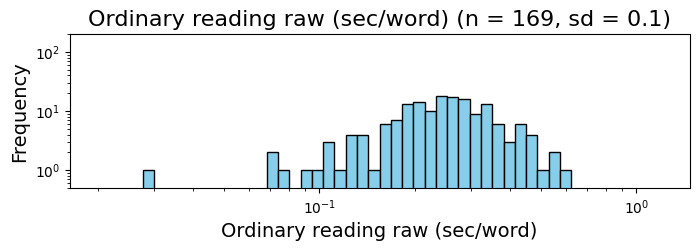

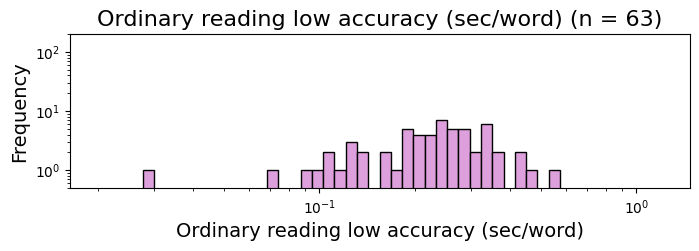

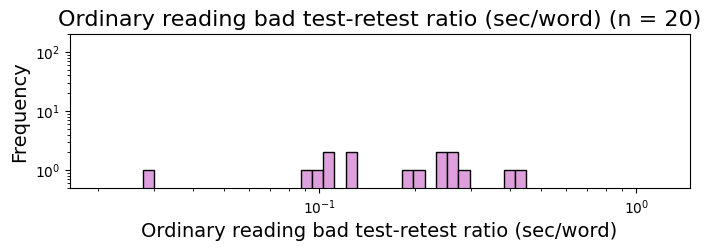

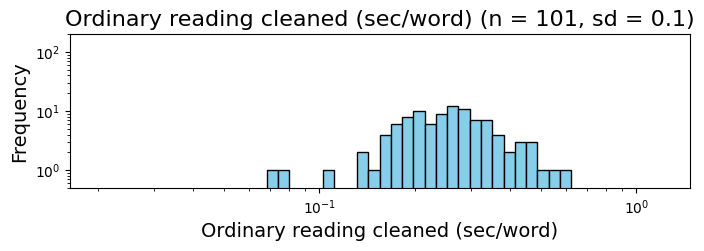

In [777]:
# SPW version
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_task_raw['gmean_threshold_task']), 'Ordinary reading raw (sec/word)', num_bins=50, min_val=0.02, max_val=1.2)
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_task_low_trial['gmean_threshold_task']), 'Ordinary reading low accuracy (sec/word)', num_bins=50, min_val=0.02, max_val=1.2, hist_color='plum', name_sd_bool=False)
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_task_bad_ratio['gmean_threshold_task']), 'Ordinary reading bad test-retest ratio (sec/word)', num_bins=50, min_val=0.02, max_val=1.2, hist_color='plum', name_sd_bool=False)
plot_threshold_array(log_wpm_to_log_spw(df_reading_gmean_task_cleaned['gmean_threshold_task']), 'Ordinary reading cleaned (sec/word)', num_bins=50, min_val=0.02, max_val=1.2)


In [778]:
df_summary_crowding_thresholds = pd.concat([summary_crowding_all_thresh, 
                                                        summary_crowding_block, 
                                                        summary_crowding_task], ignore_index=True)

display(df_summary_crowding_thresholds)
save_path = 'summary_crowding_thresholds.csv'
df_summary_crowding_thresholds.to_csv(save_path, index=False)


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,crowding,864,2.38713,2.563679,0.324394,18.284052,0.242620
1,crowding,432,2.38713,2.465265,0.369612,10.983982,0.203450
2,crowding,108,2.38713,2.388704,0.502819,8.508733,0.185039


In [779]:
df_summary_rsvp = pd.concat([df_summary_rsvp_allthresh,
                                df_summary_rsvp_block,
                                df_summary_rsvp_task])
display(df_summary_rsvp)
save_path = 'summary_rsvp_threshold.csv'
df_summary_rsvp.to_csv(save_path, index=False)

,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_log_cleaned
0,rsvp,288,1463.680337,1557.161182,333.871474,3045.424347,0.190614
0,rsvp,288,1463.680337,1557.161182,333.871474,3045.424347,0.190614
0,rsvp,144,1463.680337,1611.097598,429.768011,2933.259564,0.182752


In [780]:
df_summary_ordinary_reading_measurements = pd.concat([df_summary_reading_allThresh, 
                                                        df_summary_reading_geomean_block, 
                                                        df_summary_reading_geomean_task], ignore_index=True)

display(df_summary_ordinary_reading_measurements)
save_path = 'summary_ordinary_reading_measurements.csv'
df_summary_ordinary_reading_measurements.to_csv(save_path, index=False)


,task_name,n_cleaned,geomean_cleaned,median_cleaned,min_cleaned,max_cleaned,sd_of_logged_cleaned
0,reading_individual_measurements,404,239.087773,238.555167,60.152601,2251.407129,0.183697
1,reading_per_block,202,239.087773,242.583019,96.192040,1160.985106,0.164940
2,reading_per_task,101,239.087773,232.151054,102.993237,846.186631,0.158453


# Analysis
- note that everything in is now logged

### Functions

In [781]:
def filter_task_df(df, taskName, 
                    low_trial_ids, large_questSD_ids, bad_ratio_ids):
    '''
    filter data by number of trials, questSD, and test-retest ratio for a given task.
    '''
    df_task_raw = df[df['taskName'] == taskName]
    df_cleaned = filter_excluding_ids(df_task_raw, low_trial_ids, large_questSD_ids, bad_ratio_ids)

    return df_cleaned

In [782]:
def plot_scatter_with_correlation(var_x, var_y, var_x_name, var_y_name, plotXequalsY_bool=False, equal_axes_bool=True,
								  myticks = np.linspace(1,9,5), scatter_color='C0', axis_padding=0.05):
	"""
	Plots a scatter plot of two variables from a DataFrame and computes Pearson's r.

	Parameters:
		var_x (list): first variable extracted from a df
		var_y (list): second variable extracted from a df
		scatter_color (str): matplotlib/seaborn color for the data points
		axis_padding (float): fraction of the log10 data range to add as padding
	"""
	var_x = np.array(var_x)
	var_y = np.array(var_y)

	# print out minimum and maximum values of the variables
	min_x = var_x.min()
	min_y = var_y.min()
	max_x = var_x.max()
	max_y = var_y.max()
	print(f'Min and max values: min_x: {min_x}, max_x: {max_x}, min_y: {min_y}, max_y: {max_y}')

	# Compute Pearson correlation
	valid = (~np.isnan(var_x)) & (~np.isnan(var_y))
	r, p_value = stats.pearsonr(var_x[valid], var_y[valid])

	# Determine padded axis limits in log10 units
	x_range = max_x - min_x
	y_range = max_y - min_y
	x_pad = x_range * axis_padding if x_range > 0 else max(abs(min_x), 1) * axis_padding
	y_pad = y_range * axis_padding if y_range > 0 else max(abs(min_y), 1) * axis_padding
	min_x_val = min_x - x_pad
	max_x_val = max_x + x_pad
	min_y_val = min_y - y_pad
	max_y_val = max_y + y_pad
	if equal_axes_bool:
		joint_min = min(min_x, min_y)
		joint_max = max(max_x, max_y)
		joint_range = joint_max - joint_min
		joint_pad = joint_range * axis_padding if joint_range > 0 else max(abs(joint_min), 1) * axis_padding
		min_x_val = min_y_val = joint_min - joint_pad
		max_x_val = max_y_val = joint_max + joint_pad
	min_val = min(min_x_val, min_y_val)
	max_val = max(max_x_val, max_y_val)


	# Create the scatter plot
	plt.figure(figsize=(4, 4))  
	sns.scatterplot(x=10**var_x, y=10**var_y, s=50, alpha=0.6, color=scatter_color)

			
	# Set limits for both axes to be the same
	if equal_axes_bool:
		plt.gca().set_aspect('equal', adjustable='box')
		plt.axis('equal')


	else:
		plt.gca().set_aspect('auto', adjustable='box')  


	# Add title with Pearson's r value
	plt.title(f"measured r = {r:.2f}, N = {valid.sum()}", fontsize=16)

	# Add labels
	plt.xlabel(var_x_name, fontsize=14)
	plt.ylabel(var_y_name, fontsize=14)
	plt.xticks(fontsize=10)  
	plt.yticks(fontsize=10) 
	plt.xscale("log")
	plt.yscale("log")
	plt.xlim(10**min_x_val, 10**max_x_val)
	plt.ylim(10**min_y_val, 10**max_y_val)
	# plot x = y
	if plotXequalsY_bool:
		plt.plot([10**min_val, 10**max_val], [10**min_val, 10**max_val], color="black", linestyle="--", linewidth=1)
		

	# Create identical ticks. Keep decimal ticks intact for sec/word plots.
	ticks = np.asarray(myticks, dtype=float)
	tick_labels = [f'{t:g}' for t in ticks]
	ax = plt.gca()
        
	# force major ticks & labels exactly where you want them
	ax.xaxis.set_major_locator(FixedLocator(ticks))
	ax.xaxis.set_major_formatter(FixedFormatter(tick_labels))

	ax.yaxis.set_major_locator(FixedLocator(ticks))
	ax.yaxis.set_major_formatter(FixedFormatter(tick_labels))

	# # (optional) add minor log ticks but hide their labels
	# remove minor ticks entirely
	ax.xaxis.set_minor_locator(FixedLocator([]))
	ax.yaxis.set_minor_locator(FixedLocator([]))
	plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
	plt.tick_params(axis='both', which='major', labelsize=13)  # adjust tick label size

	# Remove top and right spines so the plot is not boxed
	sns.despine()

	# Show plot
	plt.show()


In [783]:
def make_task_wide(block_df, task_df, task_name):
    """
    block_df: columns ['prolificID','taskName','repeat','gmean_threshold_block']
    task_df : columns ['prolificID','taskName','repeat','gmean_threshold_task']
    returns: wide df with columns like ['prolificID', f'{task}_block1', ..., f'{task}_grandMean']
    """

    # 1) pivot blocks → one column per repeat
    wide_blocks = (block_df
                   .pivot(index="prolificID", columns="repeat", values="gmean_threshold_block")
                   .sort_index(axis=1))  # ensure block1, block2, ...

    # rename e.g. 1→'acuity_block1'
    wide_blocks.columns = [f"{task_name}_block{int(c)}" for c in wide_blocks.columns]

    # 2) grand mean per participant (use task_df; if multiple rows, average them)
    grand = (task_df
             .groupby("prolificID", as_index=True)["gmean_threshold_task"]
             .mean()
             .rename(f"{task_name}_grandMean")
             .to_frame())

    # combine and return
    out = wide_blocks.join(grand, how="outer").reset_index()
    return out


def build_big_df(task_to_dfs):
    """
    task_to_dfs: dict like {
        'acuity':   (acuity_gmean_block_cleaned_df,   acuity_gmean_task_cleaned_df),
        'crowding': (crowding_gmean_block_cleaned_df, crowding_gmean_task_cleaned_df),
        'rsvp':     (rsvp_gmean_block_cleaned_df,     rsvp_gmean_task_cleaned_df),
        'reading':  (reading_gmean_block_cleaned_df,  reading_gmean_task_cleaned_df),
    }
    returns one big df with prolificID rows and all task columns.
    """
    pieces = []
    for task, (block_df, task_df) in task_to_dfs.items():
        w = make_task_wide(block_df, task_df, task)
        pieces.append(w.set_index("prolificID"))

    big = pd.concat(pieces, axis=1)  # outer join on prolificID
    big = big.reset_index()
    return big

# Columns look like:
# ['prolificID', 'acuity_block1','acuity_block2',...,'acuity_grandMean',
#  'crowding_block1',...,'crowding_grandMean', 'rsvp_block1',...,'reading_grandMean']



### Filter data

In [784]:
acuity_indThresh_cleaned_df = filter_task_df(df_both_sessions, 'acuity', acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids)
crowding_indThresh_cleaned_df = filter_task_df(df_both_sessions, 'crowding', crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)
rsvp_indThresh_cleaned_df = filter_task_df(df_both_sessions, 'rsvp', rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids)
reading_indThresh_cleaned_df = filter_task_df(df_both_sessions, 'reading', reading_low_accuracy_ids, [], reading_bad_ratio_ids) 


In [785]:
acuity_gmean_meridian_cleaned_df = filter_task_df(df_gmean_meridian, 'acuity', acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids)
crowding_gmean_meridian_cleaned_df = filter_task_df(df_gmean_meridian, 'crowding', crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)
rsvp_gmean_meridian_cleaned_df = filter_task_df(df_gmean_meridian, 'rsvp', rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids)
reading_gmean_meridian_cleaned_df = filter_task_df(df_gmean_meridian, 'reading', reading_low_accuracy_ids, [], reading_bad_ratio_ids)

In [786]:
acuity_gmean_block_cleaned_df = filter_task_df(df_gmean_block, 'acuity', acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids)
crowding_gmean_block_cleaned_df = filter_task_df(df_gmean_block, 'crowding', crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)
rsvp_gmean_block_cleaned_df = filter_task_df(df_gmean_block, 'rsvp', rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids)
reading_gmean_block_cleaned_df = filter_task_df(df_gmean_block, 'reading', reading_low_accuracy_ids, [], reading_bad_ratio_ids) 

acuity_gmean_task_cleaned_df = filter_task_df(df_gmean_task, 'acuity', acuity_low_trial_ids, acuity_large_questSD_ids, acuity_bad_ratio_ids)
crowding_gmean_task_cleaned_df = filter_task_df(df_gmean_task, 'crowding', crowding_low_trial_ids, crowding_large_questSD_ids, crowding_bad_ratio_ids)
rsvp_gmean_task_cleaned_df = filter_task_df(df_gmean_task, 'rsvp', rsvp_low_trial_ids, rsvp_large_questSD_ids, rsvp_bad_ratio_ids)
reading_gmean_task_cleaned_df = filter_task_df(df_gmean_task, 'reading', reading_low_accuracy_ids, [], reading_bad_ratio_ids) 

In [787]:
# # sanity check for RSVP: if we don't exclude by test-retest ratio, we get really low r(test, retest)
# rsvp_tt = filter_task_df(df_gmean_block, 'rsvp', rsvp_low_trial_ids, [], [])
# rsvp_wide = rsvp_tt.pivot_table(
#     index=['prolificID'], columns='repeat', values='gmean_threshold_block'
# )
# rsvp_wide = rsvp_wide.rename(columns=lambda x: f"repeat{x}" if isinstance(x, (int, float)) else x)

# rsvp_r, p = stats.pearsonr(rsvp_wide['repeat1'], rsvp_wide['repeat2'])
# print(rsvp_r)

### Create and save pivot table for correlation analysis

In [788]:
task_to_dfs = {
    "acuity":   (acuity_gmean_block_cleaned_df,   acuity_gmean_task_cleaned_df),
    "crowding": (crowding_gmean_block_cleaned_df, crowding_gmean_task_cleaned_df),
    "rsvp":     (rsvp_gmean_block_cleaned_df,     rsvp_gmean_task_cleaned_df),
    "reading":  (reading_gmean_block_cleaned_df,  reading_gmean_task_cleaned_df),
}

big_df = build_big_df(task_to_dfs)

display(big_df.head())

,prolificID,acuity_block1,acuity_block2,acuity_grandMean,crowding_block1,crowding_block2,crowding_block3,crowding_block4,crowding_grandMean,rsvp_block1,rsvp_block2,rsvp_grandMean,reading_block1,reading_block2,reading_grandMean
0,559ad287fdf99b219a612d22,-0.415187,-0.480609,-0.447898,0.845687,0.882659,0.950354,1.040760,0.929865,2.523579,2.742889,2.633234,2.322498,2.234990,2.278744
1,55d51a6b8ce09000127d4821,-0.596659,-0.670809,-0.633734,0.089592,0.041552,0.119450,-0.103568,0.036757,NaN,NaN,NaN,2.398362,2.281513,2.339937
2,5685850c333cbd000d4e042f,-0.494388,-0.540586,-0.517487,NaN,NaN,NaN,NaN,NaN,3.252130,3.274171,3.263151,2.344673,2.411041,2.377857
3,56b78f11e77ebe000cbefe79,-0.463865,-0.440105,-0.451985,NaN,NaN,NaN,NaN,NaN,3.038510,3.251385,3.144948,2.538969,2.422927,2.480948
4,57334d427d01ed00098e8e69,-0.526725,-0.552582,-0.539654,0.365720,0.148872,0.053535,0.335556,0.225920,3.198827,3.096109,3.147468,2.393182,2.268736,2.330959


In [789]:
# big_df.to_csv('tidy_corr_data_short_staircase_log.csv', index=False)

### Create pivot table pt 2: include R and L thresholds, separately

In [790]:
all_tasks_indThresh_cleaned_df = pd.concat([
    acuity_indThresh_cleaned_df,
    crowding_indThresh_cleaned_df,
    rsvp_indThresh_cleaned_df,
    reading_indThresh_cleaned_df
], ignore_index=True)

In [791]:
all_tasks_indThresh_cleaned_wide = all_tasks_indThresh_cleaned_df.pivot(index="prolificID", columns=["conditionName"], values="threshold")

In [792]:
display(all_tasks_indThresh_cleaned_wide.head())

conditionName,acuity_L8_block1,acuity_L8_block2,acuity_R8_block1,acuity_R8_block2,crowding_L8_block1,crowding_L8_block2,crowding_L8_block3,crowding_L8_block4,crowding_R8_block1,crowding_R8_block2,crowding_R8_block3,crowding_R8_block4,reading_Beaver_block1,reading_Desert_block1,reading_Islands_block2,reading_Winter_block2,rsvp_foveal_block1,rsvp_foveal_block2
prolificID,,,,,,,,,,,,,,,,,,
559ad287fdf99b219a612d22,-0.375856,-0.455303,-0.454519,-0.505916,0.971440,0.981925,1.262072,1.164500,0.719934,0.783393,0.638636,0.917019,2.324647,2.299267,2.170714,2.320349,2.523579,2.742889
55d51a6b8ce09000127d4821,-0.637063,-0.711133,-0.556254,-0.630484,0.061250,-0.275240,-0.291956,-0.435274,0.117934,0.358344,0.530857,0.228138,2.422841,2.267085,2.295940,2.373882,NaN,NaN
5685850c333cbd000d4e042f,-0.525333,-0.500857,-0.463442,-0.580314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.357444,2.474570,2.347513,2.331902,3.252130,3.274171
56b78f11e77ebe000cbefe79,-0.459296,-0.401817,-0.468434,-0.478393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.557565,2.403085,2.442769,2.520374,3.038510,3.251385
57334d427d01ed00098e8e69,-0.565536,-0.546008,-0.487914,-0.559156,0.616506,0.208334,0.079096,0.504777,0.114934,0.089410,0.027973,0.166334,2.409309,2.303552,2.233921,2.377055,3.198827,3.096109


### Create pivot table pt 3: gmean for each meridian

In [793]:
meridian_dfs = {
    "acuity":   (acuity_gmean_meridian_cleaned_df),
    "crowding": (crowding_gmean_meridian_cleaned_df),
    "rsvp":     (rsvp_gmean_meridian_cleaned_df),
    "reading":  (reading_gmean_meridian_cleaned_df),
}


In [794]:
pieces = []
for task, df in meridian_dfs.items():
    wide_meridians = (df
                      .pivot(index="prolificID", columns="meridian", values="gmean_threshold_meridian")
                      .sort_index(axis=1))  # ensure block1, block2, ...
    
    # rename
    wide_meridians.columns = [f"{task}_{c}" for c in wide_meridians.columns]
               
    pieces.append(wide_meridians)

    
all_tasks_meridian_cleaned_wide = pd.concat(pieces, axis=1)  # outer join on prolificID
all_tasks_meridian_cleaned_wide = all_tasks_meridian_cleaned_wide.reset_index()                   

In [795]:
display(all_tasks_meridian_cleaned_wide.head())

,prolificID,acuity_L8,acuity_R8,crowding_L8,crowding_R8,rsvp_foveal,reading_first,reading_second
0,559ad287fdf99b219a612d22,-0.415579,-0.480217,1.094984,0.764746,2.633234,2.311957,2.245531
1,55d51a6b8ce09000127d4821,-0.674098,-0.593369,-0.235305,0.308818,NaN,2.344963,2.334911
2,5685850c333cbd000d4e042f,-0.513095,-0.521878,NaN,NaN,3.263151,2.416007,2.339707
3,56b78f11e77ebe000cbefe79,-0.430556,-0.473413,NaN,NaN,3.144948,2.480325,2.481571
4,57334d427d01ed00098e8e69,-0.555772,-0.523535,0.352178,0.099663,3.147468,2.356430,2.305488


## Test-retest

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Min and max values: min_x: -0.284862644, max_x: 0.845686695, min_y: -0.28864219649999995, max_y: 0.901201004


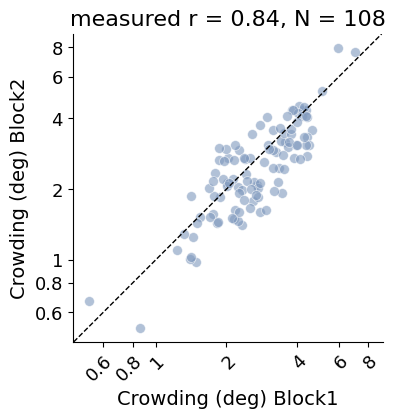

<Figure size 640x480 with 0 Axes>

In [796]:
plot_scatter_with_correlation(crowding_gmean_block_cleaned_df[crowding_gmean_block_cleaned_df['repeat']==1]['gmean_threshold_block'],
                              crowding_gmean_block_cleaned_df[crowding_gmean_block_cleaned_df['repeat']==2]['gmean_threshold_block'], 
                              'Crowding (deg) Block1', 'Crowding (deg) Block2', 
                              myticks=[0.6, 0.8, 1, 2, 4, 6, 8],
                              plotXequalsY_bool=True,
                        	  scatter_color='#7E98BD')
plt.savefig("data_figures/crowding_test_retest.svg", format="svg", bbox_inches="tight")


In [797]:
# plot_scatter_with_correlation(crowding_gmean_block_cleaned_df[crowding_gmean_block_cleaned_df['repeat']==3]['gmean_threshold_block'],
#                               crowding_gmean_block_cleaned_df[crowding_gmean_block_cleaned_df['repeat']==4]['gmean_threshold_block'], 
#                               'Crowding thresholds (log deg) block3', 'Crowding thresholds (log deg) block4', plotXequalsY_bool=True)


In [798]:
# plot_scatter_with_correlation(rsvp_gmean_block_cleaned_df[rsvp_gmean_block_cleaned_df['repeat']==1]['gmean_threshold_block'],
#                               rsvp_gmean_block_cleaned_df[rsvp_gmean_block_cleaned_df['repeat']==2]['gmean_threshold_block'], 
#                               'RSVP reading speed (log wpm) block1', 'RSVP reading speed (log wpm) block2', plotXequalsY_bool=True,
#                               myticks = np.linspace(300,3300,7),
#                         	  scatter_color='#9693C2')


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Min and max values: min_x: -1.705496565, max_x: -0.7454280639999997, min_y: -1.705496565, max_y: -0.8949633519999998


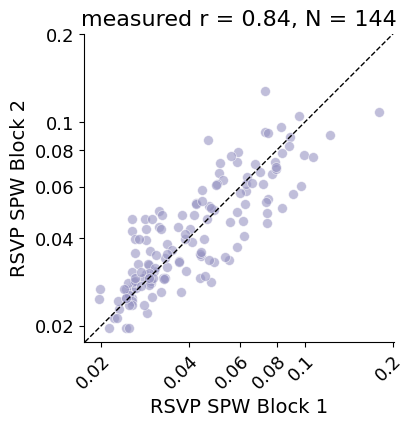

<Figure size 640x480 with 0 Axes>

In [799]:
# SPW version
plot_scatter_with_correlation(
    log_wpm_to_log_spw(rsvp_gmean_block_cleaned_df[rsvp_gmean_block_cleaned_df['repeat']==1]['gmean_threshold_block']),
    log_wpm_to_log_spw(rsvp_gmean_block_cleaned_df[rsvp_gmean_block_cleaned_df['repeat']==2]['gmean_threshold_block']),
    'RSVP SPW Block 1', 'RSVP SPW Block 2', plotXequalsY_bool=True,
    myticks=[0.02, 0.04, 0.06, 0.08, 0.1, 0.2],  # ticks in seconds/word
    scatter_color='#9693C2'
)
plt.savefig("data_figures/rsvp_reading_test_retest.svg", format="svg", bbox_inches="tight")


In [800]:
# plot_scatter_with_correlation(reading_gmean_block_cleaned_df[reading_gmean_block_cleaned_df['repeat']==1]['gmean_threshold_block'],
#                               reading_gmean_block_cleaned_df[reading_gmean_block_cleaned_df['repeat']==2]['gmean_threshold_block'], 
#                               'Ordinary reading speed (log wpm) block1', 'Ordinary reading speed (log wpm) block2', plotXequalsY_bool=True,
#                               myticks=np.linspace(200,1200,6),
#                         	  scatter_color='#7C7A7D')
							  


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Min and max values: min_x: -1.2866753978441772, max_x: -0.23685085162739283, min_y: -1.0119544201957729, max_y: -0.2049878850473401


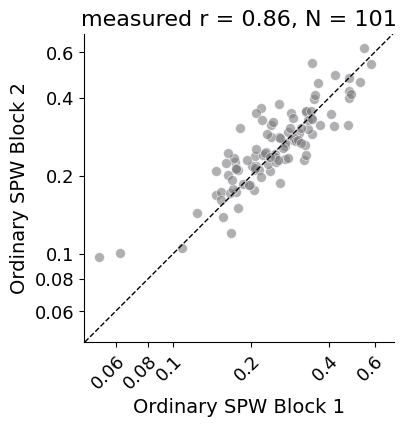

<Figure size 640x480 with 0 Axes>

In [801]:
# SPW version
plot_scatter_with_correlation(
    log_wpm_to_log_spw(reading_gmean_block_cleaned_df[reading_gmean_block_cleaned_df['repeat']==1]['gmean_threshold_block']),
    log_wpm_to_log_spw(reading_gmean_block_cleaned_df[reading_gmean_block_cleaned_df['repeat']==2]['gmean_threshold_block']),
    'Ordinary SPW Block 1', 'Ordinary SPW Block 2', plotXequalsY_bool=True,
    myticks=[0.04, 0.06, 0.08, 0.1, 0.2, 0.4, 0.6],

    scatter_color='#7C7A7D'
)
plt.savefig("data_figures/ordinary_reading_test_retest.svg", format="svg", bbox_inches="tight")


In [802]:
# plot_scatter_with_correlation(df_subj_avg, "crowding_R8", "crowding_L8", 
#                               'Crowding, right vs. left', plotXequalsY_bool=True)

In [803]:
# plot_scatter_with_correlation(df_subj_avg, "acuity_R8", "acuity_L8", 
#                               'Letter acuity, right vs. left', plotXequalsY_bool=True)

## Correlation between tasks

### Scatter plots with measured R

In [804]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# import statsmodels.api as sm
# from matplotlib.ticker import FixedLocator, FixedFormatter

# def plot_scatter_with_correlation2(var_x, var_y, var_x_name, var_y_name, 
# 								    plotXequalsY_bool=False, equal_axes_bool=True,
# 									myticks_x=np.linspace(1, 9, 5),myticks_y=np.linspace(300,3300,7),
# 									plot_best_fit_bool=True):
# 	"""
# 	Plots a scatter plot of two variables from a DataFrame and computes Pearson's r.

# 	Parameters:
# 		var_x (list): first variable extracted from a df (log10 values expected)
# 		var_y (list): second variable extracted from a df (log10 values expected)
# 	"""
# 	var_x = np.array(var_x)
# 	var_y = np.array(var_y)

# 	# print out minimum and maximum values of the variables
# 	min_x = np.nanmin(var_x)
# 	min_y = np.nanmin(var_y)
# 	max_x = np.nanmax(var_x)
# 	max_y = np.nanmax(var_y)
# 	print(f'Min and max values: min_x: {min_x}, max_x: {max_x}, min_y: {min_y}, max_y: {max_y}')
# 	# Separate axis limits (log10 space with padding)
# 	min_x_val = min_x - abs(min_x) * 0.1
# 	max_x_val = max_x + abs(max_x) * 0.1

# 	min_y_val = min_y - abs(min_y) * 0.1
# 	max_y_val = max_y + abs(max_y) * 0.1

# 	# Compute Pearson correlation
# 	valid = (~np.isnan(var_x)) & (~np.isnan(var_y))
# 	r, p_value = stats.pearsonr(var_x[valid], var_y[valid])

# 	# Determine axis limits (same for both axes, log10 space)
# 	min_val = min(min_x, min_y)
# 	min_val = min_val - abs(min_val) * 0.01
# 	max_val = max(max_x, max_y)
# 	max_val = max_val + abs(max_val) * 0.01

# 	# Create the scatter plot
# 	fig, ax = plt.subplots(figsize=(4, 4))
# 	ax = plt.gca()
# 	sns.scatterplot(x=10**var_x, y=10**var_y, s=50, alpha=0.6, ax=ax)

# 	# ---- Best-fit line + CI in log10 space, plotted on log axes ----
# 	if plot_best_fit_bool:
# 		# ensure we have enough data
# 		valid = (~np.isnan(var_x)) & (~np.isnan(var_y))
# 		if valid.sum() >= 2:
# 			import statsmodels.api as sm

# 			# fit y_log = b0 + b1 * x_log  (your var_x/var_y are already log10)
# 			X = sm.add_constant(var_x[valid])
# 			model = sm.OLS(var_y[valid], X).fit()

# 			# use your padded min/max (log space) to span the plotted range
# 			x_pred_log = np.linspace(min_x_val, max_x_val, 200)
# 			X_pred = sm.add_constant(x_pred_log)
# 			pred = model.get_prediction(X_pred).summary_frame(alpha=0.05)

# 			y_hat_log = pred['mean'].to_numpy()
# 			y_lo_log  = pred['mean_ci_lower'].to_numpy()
# 			y_hi_log  = pred['mean_ci_upper'].to_numpy()

# 			# convert to linear for plotting on log axes
# 			x_pred = 10**x_pred_log
# 			y_hat  = 10**y_hat_log
# 			y_lo   = 10**y_lo_log
# 			y_hi   = 10**y_hi_log

# 			# set limits BEFORE plotting lines to avoid clipping (log scale)
# 			ax.set_xscale("log")
# 			ax.set_yscale("log")

# 			# if you want the same range padding applied to the line visibility
# 			ax.set_xlim(10**min_x, 10**max_x)
# 			ax.set_ylim(10**min_y, 10**max_y)

# 			# draw CI then the line, with high zorder so it’s on top of points
# 			ax.fill_between(x_pred, y_lo, y_hi, alpha=0.2, linewidth=0, zorder=3)
# 			ax.plot(x_pred, y_hat, linewidth=2, zorder=4)

# 	# Equal aspect handling (works on log axes)
# 	if equal_axes_bool:
# 		ax.set_aspect('equal', adjustable='box')
# 		plt.axis('equal')
# 	else:
# 		ax.set_aspect('auto', adjustable='box')

# 	# Title with r
# 	plt.title(f"measured r = {r:.2f}", fontsize=16)

# 	# Labels
# 	plt.xlabel(var_x_name, fontsize=14)
# 	plt.ylabel(var_y_name, fontsize=14)
# 	plt.xticks(fontsize=10)
# 	plt.yticks(fontsize=10)


# 	# Set limits after plotting
# 	plt.xlim(10**min_x_val, 10**max_x_val)
# 	plt.ylim(10**min_y_val, 10**max_y_val)
# 	# x = y reference (use your log-space min/max)
# 	if plotXequalsY_bool:
# 		ax.plot([10**min_val, 10**max_val], [10**min_val, 10**max_val],
# 				color="black", linestyle="--", linewidth=1, zorder=2)

# 	# # Identical integer ticks you specified
# 	xticks = np.round(myticks_x).astype(int)
# 	yticks = np.round(myticks_y).astype(int)
# 	ax.xaxis.set_major_locator(FixedLocator(xticks))
# 	ax.xaxis.set_major_formatter(FixedFormatter([str(t) for t in xticks]))
# 	ax.yaxis.set_major_locator(FixedLocator(yticks))
# 	ax.yaxis.set_major_formatter(FixedFormatter([str(t) for t in yticks]))
# 	ax.xaxis.set_minor_locator(FixedLocator([]))
# 	ax.yaxis.set_minor_locator(FixedLocator([]))

# 	plt.xticks(rotation=45, ha="right")
# 	plt.show()


In [805]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FixedLocator, FixedFormatter

def plot_scatter_with_correlation2(var_x, var_y, var_x_name, var_y_name, 
                                   plotXequalsY_bool=False, equal_axes_bool=True,
                                   myticks_x=np.linspace(1, 9, 5), myticks_y=np.linspace(300,3300,7),
                                   plot_best_fit_bool=True,
                                   n_boot=2000, random_state=None, axis_padding=0.05):
    """
    Plots a scatter plot (linear units) of two log10 variables and computes Pearson's r in log space.
    If plot_best_fit_bool=True, draws the best-fit line (log-log) and a 68% bootstrap CI band (16th–84th).
    """
    var_x = np.array(var_x, dtype=float)
    var_y = np.array(var_y, dtype=float)

    # Print ranges (in log10)
    min_x = np.nanmin(var_x); max_x = np.nanmax(var_x)
    min_y = np.nanmin(var_y); max_y = np.nanmax(var_y)
    print(f'Min and max values: min_x: {min_x}, max_x: {max_x}, min_y: {min_y}, max_y: {max_y}')

    # Same padding rule for x and y, computed in log10 space
    x_range = max_x - min_x
    y_range = max_y - min_y
    x_pad = x_range * axis_padding if x_range > 0 else max(abs(min_x), 1) * axis_padding
    y_pad = y_range * axis_padding if y_range > 0 else max(abs(min_y), 1) * axis_padding
    min_x_val = min_x - x_pad
    max_x_val = max_x + x_pad
    min_y_val = min_y - y_pad
    max_y_val = max_y + y_pad

    # Pearson r (log space)
    valid = (~np.isnan(var_x)) & (~np.isnan(var_y))
    if valid.sum() < 2:
        r, p_value = np.nan, np.nan
    else:
        r, p_value = stats.pearsonr(var_x[valid], var_y[valid])

    # Joint range (for x=y line)
    min_val = min(min_x_val, min_y_val)
    max_val = max(max_x_val, max_y_val)

    # Scatter (plot in linear units; axes will be log-scaled)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax = plt.gca()
    sns.scatterplot(x=10**var_x, y=10**var_y, s=50, alpha=0.6, ax=ax)

    # ----- Best-fit line + 68% bootstrap CI (fit in log space) -----
    if plot_best_fit_bool and valid.sum() >= 2:
        x_log = var_x[valid]
        y_log = var_y[valid]

        # Grid to predict on (log space), then convert to linear for plotting
        x_pred_log = np.linspace(min_x_val, max_x_val, 200)

        # Closed-form OLS in log space for the original line
        # slope, intercept from polyfit in log space
        b1, b0 = np.polyfit(x_log, y_log, 1)
        y_hat_log = b0 + b1 * x_pred_log

        # ---- Bootstrap 68% CI (16th–84th percentiles) ----
        rng = np.random.default_rng(random_state)
        n = x_log.size
        boot_preds = np.empty((n_boot, x_pred_log.size), dtype=float)

        # Vectorized-ish bootstrap: resample indices; fit line in log space; predict
        for i in range(n_boot):
            idx = rng.integers(0, n, size=n)
            xb = x_log[idx]
            yb = y_log[idx]
            # Guard against degenerate samples (all xb equal)
            if np.allclose(xb, xb[0]):
                # fallback: use original fit for this draw
                boot_preds[i, :] = y_hat_log
                continue
            b1_b, b0_b = np.polyfit(xb, yb, 1)
            boot_preds[i, :] = b0_b + b1_b * x_pred_log

        # 68% central interval in log space, then convert to linear
        y_lo_log = np.percentile(boot_preds, 16, axis=0)
        y_hi_log = np.percentile(boot_preds, 84, axis=0)

        x_pred = 10**x_pred_log
        y_hat  = 10**y_hat_log
        y_lo   = 10**y_lo_log
        y_hi   = 10**y_hi_log

        # Log axes
        ax.set_xscale("log")
        ax.set_yscale("log")

        # Draw CI band first, then the line
        ax.fill_between(x_pred, y_lo, y_hi, alpha=0.25, linewidth=0, zorder=3)
        ax.plot(x_pred, y_hat, linewidth=2, zorder=4)

    # Aspect
    if equal_axes_bool:
        ax.set_aspect('equal', adjustable='box')
        plt.axis('equal')
    else:
        ax.set_aspect('auto', adjustable='box')

    # Title & labels
    plt.title(f"measured r = {r:.2f}" if np.isfinite(r) else "measured r = N/A", fontsize=16)
    plt.xlabel(var_x_name, fontsize=14)
    plt.ylabel(var_y_name, fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Final padded limits (linear units)
    plt.xlim(10**min_x_val, 10**max_x_val)
    plt.ylim(10**min_y_val, 10**max_y_val)

    # Optional x=y reference in linear units
    if plotXequalsY_bool:
        ax.plot([10**min_val, 10**max_val], [10**min_val, 10**max_val],
                color="black", linestyle="--", linewidth=1, zorder=2)

    # Manual ticks (fixed positions on log axes). Keep decimal ticks intact for sec/word plots.
    xticks = np.asarray(myticks_x, dtype=float)
    yticks = np.asarray(myticks_y, dtype=float)
    ax.xaxis.set_major_locator(FixedLocator(xticks))
    ax.xaxis.set_major_formatter(FixedFormatter([f'{t:g}' for t in xticks]))
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FixedFormatter([f'{t:g}' for t in yticks]))
    ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.yaxis.set_minor_locator(FixedLocator([]))

    plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
    plt.tick_params(axis='both', which='major', labelsize=13)  
    sns.despine(ax=ax)
    plt.show()


In [806]:
# plot_scatter_with_correlation2(big_df['crowding_grandMean'],
#                               big_df['rsvp_grandMean'], 
#                               'Crowding (log deg)', 'RSVP reading speed (log wpm)',
# 							  myticks_x=[1, 2, 4, 8],myticks_y=[300, 600, 1200, 2400, 4800])


In [807]:
# # SPW version
# plot_scatter_with_correlation2(
#     big_df['crowding_grandMean'],
#     log_wpm_to_log_spw(big_df['rsvp_grandMean']),
#     'Crowding (log deg)', 'RSVP reading (sec/word)',
#     myticks_x=[1, 2, 4, 8], myticks_y=[0.0125, 0.025, 0.05, 0.1, 0.2]
# )


In [808]:
# plot_scatter_with_correlation2(big_df['crowding_grandMean'],
#                               big_df['reading_grandMean'], 
#                               'Crowding (log deg)', 'Ordinary reading speed (log wpm)',
# 									myticks_x=[1, 2, 4, 8],myticks_y=[100, 200, 400, 800])
									


In [809]:
# # SPW version
# plot_scatter_with_correlation2(
#     big_df['crowding_grandMean'],
#     log_wpm_to_log_spw(big_df['reading_grandMean']),
#     'Crowding (log deg)', 'Ordinary reading (sec/word)',
#     myticks_x=[1, 2, 4, 8], myticks_y=[0.075, 0.15, 0.3, 0.6]
# )


In [810]:
# plot_scatter_with_correlation2(big_df['rsvp_grandMean'],
#                               big_df['reading_grandMean'], 
#                               'RSVP reading speed (wpm)', 'Ordinary reading speed (wpm)',
# 									myticks_x=[300, 600, 1200, 2400, 4800],myticks_y=[100, 200, 400, 800])
									

In [811]:
# # SPW version
# plot_scatter_with_correlation2(
#     log_wpm_to_log_spw(big_df['rsvp_grandMean']),
#     log_wpm_to_log_spw(big_df['reading_grandMean']),
#     'RSVP reading (sec/word)', 'Ordinary reading (sec/word)',
#     myticks_x=[0.0125, 0.025, 0.05, 0.1, 0.2], myticks_y=[0.075, 0.15, 0.3, 0.6]
# )


In [812]:
x_crowding = np.array(big_df['crowding_grandMean'], dtype=float)
y_rsvp = np.array(big_df['rsvp_grandMean'], dtype=float)
y_reading = np.array(big_df['reading_grandMean'], dtype=float)

valid_rsvp = (~np.isnan(x_crowding)) & (~np.isnan(y_rsvp))
valid_reading = (~np.isnan(x_crowding)) & (~np.isnan(y_reading))

xlim = (0.3, 9)
ylim = (100, 6400)
xlim_log = np.log10(xlim)
ylim_log = np.log10(ylim)

def draw_fit_with_ci(ax, x_log, y_log, x_pred_log, color, label, n_boot=2000, random_state=None):
    if x_log.size < 2:
        return
    slope, intercept = np.polyfit(x_log, y_log, 1)
    y_hat_log = intercept + slope * x_pred_log

    rng = np.random.default_rng(random_state)
    boot_preds = np.empty((n_boot, x_pred_log.size), dtype=float)
    n = x_log.size
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb = x_log[idx]
        yb = y_log[idx]
        if np.allclose(xb, xb[0]):
            boot_preds[i, :] = y_hat_log
            continue
        slope_b, intercept_b = np.polyfit(xb, yb, 1)
        boot_preds[i, :] = intercept_b + slope_b * x_pred_log

    y_lo_log = np.percentile(boot_preds, 16, axis=0)
    y_hi_log = np.percentile(boot_preds, 84, axis=0)
    x_pred = 10**x_pred_log
    y_hat = 10**y_hat_log
    y_lo = 10**y_lo_log
    y_hi = 10**y_hi_log

    ax.fill_between(x_pred, y_lo, y_hi, color=color, alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_pred, y_hat, color=color, linewidth=2, label=f'{label} fit', zorder=3)

x_pred_log = np.linspace(xlim_log[0], xlim_log[1], 200)
fig_width = 8
fig_height = fig_width * ((ylim_log[1] - ylim_log[0]) / (xlim_log[1] - xlim_log[0]))
# fig, ax = plt.subplots(figsize=(fig_width, fig_height))
# ax.scatter(10**x_crowding[valid_rsvp], 10**y_rsvp[valid_rsvp],
#            s=50, alpha=0.65, color='#9693C2', label='RSVP reading')
# ax.scatter(10**x_crowding[valid_reading], 10**y_reading[valid_reading],
#            s=50, alpha=0.65, color='#7C7A7D', label='Ordinary reading')
# draw_fit_with_ci(ax, x_crowding[valid_rsvp], y_rsvp[valid_rsvp], x_pred_log, '#9693C2', 'RSVP reading', random_state=0)
# draw_fit_with_ci(ax, x_crowding[valid_reading], y_reading[valid_reading], x_pred_log, '#7C7A7D', 'Ordinary reading', random_state=1)

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlim(xlim)
# ax.set_ylim(80, 6400)
# ax.set_aspect('equal', adjustable='box')
# ax.set_xlabel('Crowding (deg)', fontsize=14)
# ax.set_ylabel('Reading speed (wpm)', fontsize=14)

# ax.xaxis.set_major_locator(FixedLocator([1, 3, 5, 7, 9]))
# ax.xaxis.set_major_formatter(FixedFormatter(['1', '3', '5', '7', '9']))
# ax.yaxis.set_major_locator(FixedLocator([100, 200, 400, 800, 1600, 3200, 6400]))
# ax.yaxis.set_major_formatter(FixedFormatter(['100', '200', '400', '800', '1600', '3200', '6400']))
# ax.xaxis.set_minor_locator(FixedLocator([]))
# ax.yaxis.set_minor_locator(FixedLocator([]))

# # ax.legend(frameon=False)
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
# plt.tick_params(axis='both', which='major', labelsize=13)
# sns.despine(ax=ax)
# plt.show()


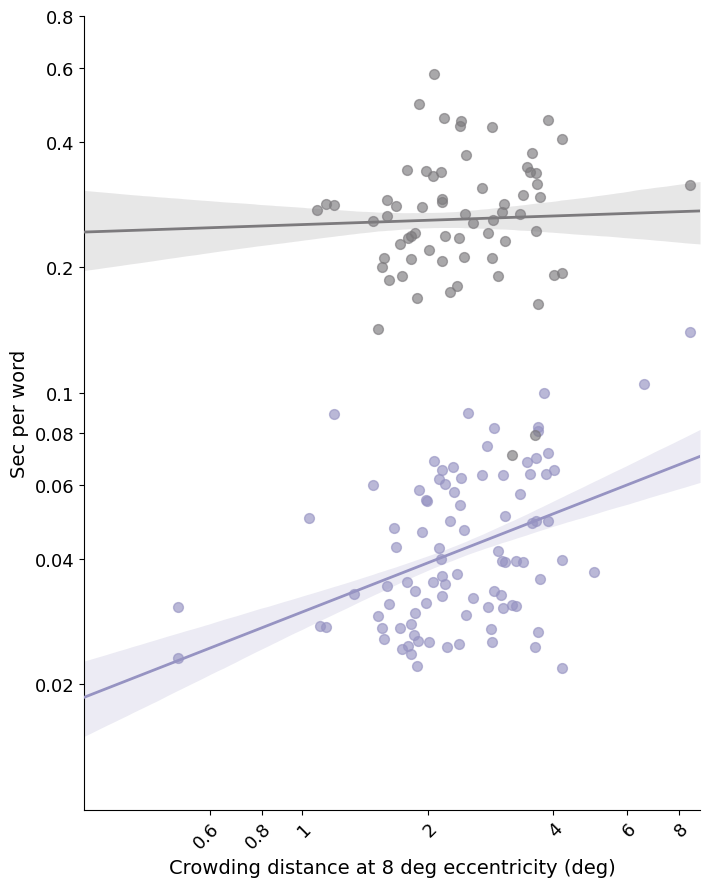

<Figure size 640x480 with 0 Axes>

In [815]:
# SPW version
x_crowding = np.array(big_df['crowding_grandMean'], dtype=float)
y_rsvp = np.array(log_wpm_to_log_spw(big_df['rsvp_grandMean']), dtype=float)
y_reading = np.array(log_wpm_to_log_spw(big_df['reading_grandMean']), dtype=float)

valid_rsvp = (~np.isnan(x_crowding)) & (~np.isnan(y_rsvp))
valid_reading = (~np.isnan(x_crowding)) & (~np.isnan(y_reading))

xlim = (0.3, 9)
ylim = (0.01, 0.8)
xlim_log = np.log10(xlim)
ylim_log = np.log10(ylim)

x_pred_log = np.linspace(xlim_log[0], xlim_log[1], 200)
fig_width = 8

fig_height = fig_width * ((ylim_log[1] - ylim_log[0]) / (xlim_log[1] - xlim_log[0]))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.scatter(10**x_crowding[valid_rsvp], 10**y_rsvp[valid_rsvp],
           s=50, alpha=0.65, color='#9693C2', label='RSVP reading')
ax.scatter(10**x_crowding[valid_reading], 10**y_reading[valid_reading],
           s=50, alpha=0.65, color='#7C7A7D', label='Ordinary reading')
draw_fit_with_ci(ax, x_crowding[valid_rsvp], y_rsvp[valid_rsvp], x_pred_log, '#9693C2', 'RSVP reading', random_state=0)
draw_fit_with_ci(ax, x_crowding[valid_reading], y_reading[valid_reading], x_pred_log, '#7C7A7D', 'Ordinary reading', random_state=1)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Crowding distance at 8 deg eccentricity (deg)', fontsize=14)
ax.set_ylabel('Sec per word', fontsize=14)


ax.xaxis.set_major_locator(FixedLocator([0.6, 0.8, 1, 2, 4, 6, 8]))
ax.xaxis.set_major_formatter(FixedFormatter(['0.6', '0.8', '1', '2', '4', '6', '8']))
ax.yaxis.set_major_locator(FixedLocator([0.02, 0.04, 0.06, 0.08, 0.1, 0.2, 0.4, 0.6, 0.8]))
ax.yaxis.set_major_formatter(FixedFormatter(['0.02', '0.04', '0.06', '0.08', '0.1', '0.2', '0.4', '0.6', '0.8']))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.yaxis.set_minor_locator(FixedLocator([]))

# ax.legend(frameon=False)
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.tick_params(axis='both', which='major', labelsize=13)
sns.despine(ax=ax)
plt.show()
plt.savefig("data_figures/reading_vs_crowding.svg", format="svg", bbox_inches="tight")

